<a href="https://colab.research.google.com/github/khrahaman/Gradient-Inversion-Attack/blob/main/Gradient_Inversion_Attack_InverseFed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Noise Calibration:

import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np


#Dataset (MNIST) Loading and Preprocessing
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, y_train = x_train[:2000], y_train[:2000]

x_train, x_test = x_train.astype("float32"), x_test.astype("float32")
y_train, y_test = y_train.flatten(), y_test.flatten()


def prep(x):
        x = np.expand_dims(x, axis=-1)  # (N, 28,28,1)
        # Resize to 32x32
        x = tf.image.resize(x, [32, 32]).numpy()  # (N,32,32,1)
        # replicate channel to make 3 channels
        x = np.repeat(x, 3, axis=-1)  # (N,32,32,3)
        return x

x_train = prep(x_train)
x_test = prep(x_test)


# Split Data among clients
num_clients = 2
data_per_client = len(x_train) // num_clients
print(data_per_client)
client_data = [(x_train[i * data_per_client:(i + 1) * data_per_client],
                y_train[i * data_per_client:(i + 1) * data_per_client])
               for i in range(num_clients)]

#input_shape = (32, 32, 3) # for cifar-10
#input_shape = (28,28,1) # for mnist and fmnist

num_classes = 10
batch_size = 8
epochs = 5





11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


2025-12-05 04:11:49.698067: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


1000


In [ ]:
#LeNet

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, AveragePooling2D, Flatten, Dense

def build_model(input_shape=(32, 32, 3), num_classes=10):
    with tf.device('/cpu:0'):
        inputs = Input(shape=input_shape)
        # C1: 6 filters, 5x5, tanh
        x = Conv2D(6, (5, 5), activation='tanh', padding='valid', name='C1')(inputs)
        # S2: Average pooling 2x2, stride 2
        x = AveragePooling2D(pool_size=(2, 2), name='S2')(x)
        # C3: 16 filters, 5x5, tanh
        x = Conv2D(16, (5, 5), activation='tanh', padding='valid', name='C3')(x)
        # S4: Average pooling 2x2, stride 2
        x = AveragePooling2D(pool_size=(2, 2), name='S4')(x)
        # Flatten
        x = Flatten(name='Flatten')(x)
        # F5: Dense 120, tanh
        x = Dense(120, activation='tanh', name='F5')(x)
        # F6: Dense 84, tanh
        x = Dense(84, activation='tanh', name='F6')(x)
        # Output: Softmax for 10 classes
        outputs = Dense(num_classes, activation='softmax', name='Output')(x)

    return Model(inputs, outputs, name='LeNet')




import time

global_accs = []
global_models = []

#def evaluate_global_model(model):
#    logits = model(x_test, training=False)
#    preds = tf.argmax(logits, axis=1)
#    acc = tf.reduce_mean(tf.cast(tf.equal(preds, y_test), tf.float32))
#    global_accs.append(acc)
#    print(f"Global Test Accuracy: {acc.numpy():.4f}")

def evaluate_global_model(model):
    batch_size = 512
    num_samples = len(x_test)
    preds = []
    for i in range(0, num_samples, batch_size):
        batch_x = x_test[i:i+batch_size]
        logits = model(batch_x, training=False)
        batch_preds = tf.argmax(logits, axis=1)
        preds.extend(batch_preds.numpy())
    preds = tf.convert_to_tensor(preds)
    acc = tf.reduce_mean(tf.cast(tf.equal(preds, y_test), tf.float32))
    global_accs.append(acc)
    print(f"Global Test Accuracy: {acc.numpy():.4f}")

# Training
models = []
for _ in range(num_clients):
    model = build_model()  # build the model without splitting
    models.append(model)

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=1000,
    decay_rate=0.9
)
optimizers = [tf.keras.optimizers.Adam(learning_rate=lr_schedule) for _ in range(num_clients)]

# FedAvg
def average_trainable_weights_weighted(model_list, sample_counts):
    new_weights = []
    total_samples = sum(sample_counts)
    for weights in zip(*[model.trainable_weights for model in model_list]):
        weighted_sum = sum(w.numpy() * (count / total_samples)
                           for w, count in zip(weights, sample_counts))
        new_weights.append(weighted_sum)
    return new_weights

def set_trainable_weights(model, new_weights):
    for var, new in zip(model.trainable_weights, new_weights):
        var.assign(new)

client_accuracies = [[] for _ in range(num_clients)]
client_time = [[] for _ in range(num_clients)]

client_grads = []
aggregated_grads = []
for epoch in range(epochs):
    print(f"\n🌀 Epoch {epoch + 1}/{epochs}")
    epoch_client_grads = []
    for client_id, (x_client, y_client) in enumerate(client_data):
        start_time = time.time()

        train_ds = tf.data.Dataset.from_tensor_slices((x_client, y_client)).shuffle(1000).batch(batch_size)
        model = models[client_id]

        for step, (x_batch, y_batch) in enumerate(train_ds):
            with tf.GradientTape() as tape:
                logits = model(x_batch, training=True)
                loss = loss_fn(y_batch, logits)
                acc = tf.reduce_mean(tf.cast(tf.equal(tf.argmax(logits, axis=1), tf.cast(y_batch, tf.int64)), tf.float32))

            grads = tape.gradient(loss, model.trainable_variables)
            epoch_client_grads.append(grads)
            optimizers[client_id].apply_gradients(zip(grads, model.trainable_variables))

            if step % 100 == 0:
                print(f"Client {client_id}, Step {step}, Loss: {loss.numpy():.4f}, Accuracy: {acc.numpy():.4f}")

        end_time = time.time()
        print(f"Time taken: {end_time - start_time}")

    # Compute aggregated gradients
    aggregated_grad = []
    for grads in zip(*epoch_client_grads):
        aggregated_grad.append(tf.reduce_mean(grads, axis=0))
    aggregated_grads.append(aggregated_grad)

    # Update models with aggregated gradients
    sample_counts = [len(data[0]) for data in client_data]
    avg_weights = average_trainable_weights_weighted(models, sample_counts)
    for model in models:
        set_trainable_weights(model, avg_weights)

    client_grads.append(epoch_client_grads)
    global_models.append(models[0])
    evaluate_global_model(models[0])



🌀 Epoch 1/5
Client 0, Step 0, Loss: 2.1118, Accuracy: 0.3750
Client 0, Step 100, Loss: 0.1020, Accuracy: 1.0000
Time taken: 8.266018152236938
Client 1, Step 0, Loss: 2.5066, Accuracy: 0.0000
Client 1, Step 100, Loss: 0.2896, Accuracy: 1.0000
Time taken: 8.252315044403076
Global Test Accuracy: 0.6573

🌀 Epoch 2/5
Client 0, Step 0, Loss: 1.7817, Accuracy: 0.7500
Client 0, Step 100, Loss: 1.1355, Accuracy: 0.6250
Time taken: 7.9700233936309814
Client 1, Step 0, Loss: 1.7055, Accuracy: 0.6250
Client 1, Step 100, Loss: 0.2160, Accuracy: 1.0000
Time taken: 8.136864185333252
Global Test Accuracy: 0.8904

🌀 Epoch 3/5
Client 0, Step 0, Loss: 0.5928, Accuracy: 0.8750
Client 0, Step 100, Loss: 0.1072, Accuracy: 1.0000
Time taken: 8.149539232254028
Client 1, Step 0, Loss: 0.1145, Accuracy: 1.0000
Client 1, Step 100, Loss: 0.4644, Accuracy: 0.8750
Time taken: 8.108671188354492
Global Test Accuracy: 0.9116

🌀 Epoch 4/5
Client 0, Step 0, Loss: 0.2500, Accuracy: 0.8750
Client 0, Step 100, Loss: 0.166


--- Attacking client 0 at epoch 4 (avg over client's 125 steps) ---
> Restart 1/2


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/nn.py:666: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


 iter 0  total_loss 168.795731  grad_loss 9.66522217  tv 15911  ent 2.01649261
 iter 400  total_loss 8.99868  grad_loss 4.51643181  tv 448.197693  ent 0.00543887308
 iter 800  total_loss 8.91964722  grad_loss 4.52310085  tv 439.632446  ent 0.0018339972
 iter 1200  total_loss 8.84135532  grad_loss 4.51333904  tv 432.781  ent 0.000935912
 iter 1600  total_loss 8.76005173  grad_loss 4.44007778  tv 431.977478  ent 0.000565762166
 iter 2000  total_loss 8.68343449  grad_loss 4.42698  tv 425.625885  ent 0.00037484747
 iter 2400  total_loss 8.80455685  grad_loss 4.50122  tv 430.31427  ent 0.000262922753
 iter 2800  total_loss 8.88599777  grad_loss 4.57394695  tv 431.185913  ent 0.0001916131
 iter 2999  total_loss 8.88817501  grad_loss 4.55717182  tv 433.081116  ent 0.000165474528
 Restart 1 best_loss 8.682112
> Restart 2/2
 iter 0  total_loss 167.35965  grad_loss 9.89095  tv 15744.8535  ent 1.98388577
 iter 400  total_loss 9.16238499  grad_loss 4.47939634  tv 468.271  ent 0.00530002266
 iter 8

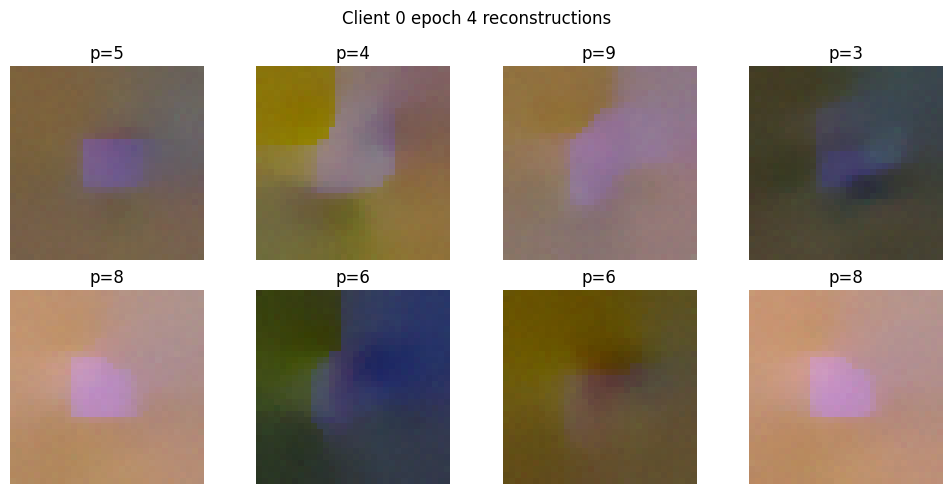

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


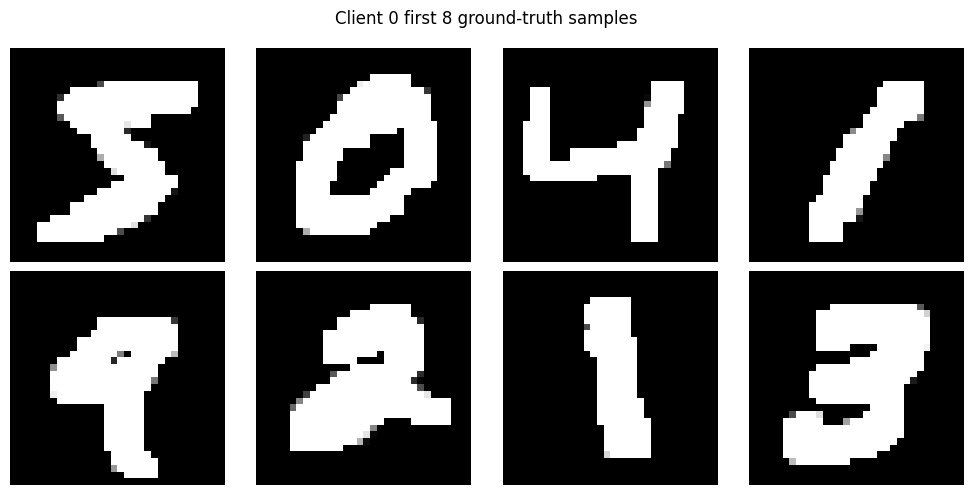

In [ ]:
# ---------- GradInversion tuned for LeNet + visualization ----------
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# -------------------- Settings (tweak these) --------------------
# Make sure these match your training config
num_clients = 2               # you said 2 clients
local_dataset_size = 1000     # each client used 1000 MNIST/CIFAR-style samples
local_batch_size = 8          # you stated batch size=8 in training
image_shape = (32, 32, 3)     # your LeNet input
target_epochs = list(range(len(client_grads)))  # [0..4] in your case

# Attack hyperparams
attack_iters = 3000
attack_lr = 0.05
tv_weight = 1e-2
l2_weight = 1e-3
entropy_weight = 1e-2
n_restarts = 2
print_every = 400

# ---------- Utilities ----------
def per_layer_cosine_loss(grads_cur, grads_target, eps=1e-8):
    loss = 0.0
    for g_cur, g_tgt in zip(grads_cur, grads_target):
        g_cur_f = tf.reshape(g_cur, [-1])
        g_tgt_f = tf.reshape(g_tgt, [-1])
        # if both zero, skip to avoid NaNs
        if tf.reduce_sum(tf.abs(g_cur_f)) < 1e-12 and tf.reduce_sum(tf.abs(g_tgt_f)) < 1e-12:
            continue
        dot = tf.reduce_sum(g_cur_f * g_tgt_f)
        denom = tf.norm(g_cur_f) * tf.norm(g_tgt_f) + eps
        cos = dot / denom
        loss += (1.0 - cos)
    return loss

def total_variation(x):
    return tf.reduce_sum(tf.image.total_variation(x))

def l2_pixel(x):
    return tf.reduce_mean(tf.square(x))

def entropy_of_soft_labels(y_soft):
    y = tf.clip_by_value(y_soft, 1e-8, 1.0)
    ent = -tf.reduce_mean(tf.reduce_sum(y * tf.math.log(y), axis=-1))
    return ent

# ---------- Helpers to extract/average grads from your storage format ----------
def steps_per_client_from_epoch(epoch_idx):
    steps_total = len(client_grads[epoch_idx])  # e.g. 250
    if steps_total % num_clients != 0:
        raise ValueError(f"Total steps {steps_total} not divisible by num_clients {num_clients}")
    return steps_total // num_clients

def avg_steps_to_target_grads(epoch_idx, client_id):
    """
    - client_grads[epoch_idx] is a flat list of per-step gradient-lists.
    - We group into clients sequentially: first steps_per_client elements for client 0, next for client1, etc.
    - Average per-layer across that client's steps to produce the target_grads for attack.
    """
    steps_total = len(client_grads[epoch_idx])
    s_per_client = steps_per_client_from_epoch(epoch_idx)
    start = client_id * s_per_client
    end = start + s_per_client
    steps_list = client_grads[epoch_idx][start:end]  # list length s_per_client, each entry is list of 10 tensors

    # stack and mean per layer
    n_layers = len(steps_list[0])
    averaged = []
    for layer_idx in range(n_layers):
        layer_steps = [tf.cast(step[layer_idx], tf.float32) for step in steps_list]
        stacked = tf.stack(layer_steps, axis=0)  # shape [steps, ...]
        averaged.append(tf.reduce_mean(stacked, axis=0))
    return averaged

def aggregated_grads_for_epoch(epoch_idx):
    # aggregated_grads[epoch_idx] is already a list of 10 tensors (per your printout)
    return [tf.cast(g, tf.float32) for g in aggregated_grads[epoch_idx]]

# ---------- Attack core (optimized for LeNet shapes/order) ----------
def attack_on_target_grads(model,
                           target_grads,
                           batch_size,
                           image_shape=(32,32,3),
                           iters=2000,
                           lr=0.05,
                           tv_weight=1e-3,
                           l2_weight=1e-4,
                           entropy_weight=1e-3,
                           n_restarts=2,
                           use_label_opt=True,
                           print_every=200):
    out_best_loss = float('inf')
    out_best = None
    out_best_labels = None

    loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=True)

    for restart in range(n_restarts):
        tf.print(f"> Restart {restart+1}/{n_restarts}")
        # initialize x_hat and label logits
        x_hat = tf.Variable(tf.random.uniform([batch_size, *image_shape], 0.0, 1.0), dtype=tf.float32)
        if use_label_opt:
            y_logits = tf.Variable(tf.random.normal([batch_size, model.output_shape[-1]]), dtype=tf.float32)
        else:
            y_logits = tf.Variable(tf.zeros([batch_size, model.output_shape[-1]]), dtype=tf.float32)

        opt = tf.keras.optimizers.Adam(learning_rate=lr)
        best_loss = float('inf')
        best_x = None
        best_y = None

        for i in range(iters):
            with tf.GradientTape() as tape:
                y_soft = tf.nn.softmax(y_logits, axis=-1)

                # compute grads of (fake batch loss) w.r.t. model params
                with tf.GradientTape() as inner:
                    logits = model(x_hat, training=True)
                    loss = loss_fn(y_soft, logits)
                grads_cur = inner.gradient(loss, model.trainable_variables)

                grad_loss = per_layer_cosine_loss(grads_cur, target_grads)
                tv = total_variation(x_hat)
                l2p = l2_pixel(x_hat)
                ent = entropy_of_soft_labels(y_soft)

                total_loss = grad_loss + tv_weight * tv + l2_weight * l2p + entropy_weight * ent

            grads_vars = tape.gradient(total_loss, [x_hat, y_logits])
            # apply gradients (note: y_logits always present in our code)
            opt.apply_gradients(zip(grads_vars, [x_hat, y_logits]))

            x_hat.assign(tf.clip_by_value(x_hat, 0.0, 1.0))

            if (i % print_every == 0) or (i == iters - 1):
                tf.print(" iter", i, " total_loss", total_loss, " grad_loss", grad_loss, " tv", tv, " ent", ent)
            if total_loss.numpy() < best_loss:
                best_loss = total_loss.numpy()
                best_x = x_hat.numpy().copy()
                best_y = tf.nn.softmax(y_logits, axis=-1).numpy().copy()

        tf.print(" Restart", restart+1, "best_loss", best_loss)
        if best_loss < out_best_loss:
            out_best_loss = best_loss
            out_best = best_x
            out_best_labels = best_y

    return out_best, out_best_labels, out_best_loss

# ---------- Visualization ----------
def show_reconstructions(x_recon, labels_soft=None, ncol=4, title="Reconstructions", compare_with=None):
    """
    x_recon: numpy array [B,H,W,C]
    labels_soft: optional [B, num_classes]
    compare_with: optional list/array of ground-truth images to show next to reconstructions (same shape)
    """
    B = x_recon.shape[0]
    ncol = min(ncol, B)
    nrow = (B + ncol - 1) // ncol
    plt.figure(figsize=(ncol * 2.5, nrow * 2.5))
    for i in range(B):
        ax = plt.subplot(nrow, ncol, i+1)
        img = x_recon[i]
        # if grayscale (C==1), squeeze
        if img.shape[-1] == 1:
            plt.imshow(img.squeeze(), cmap='gray', vmin=0, vmax=1)
        else:
            plt.imshow(img)
        title_str = ""
        if labels_soft is not None:
            pred_label = np.argmax(labels_soft[i])
            title_str = f"p={pred_label}"
        if compare_with is not None:
            ax.set_xlabel(title_str)
            # show true image border in green if similar? for now just show label/title
            # We will show compare images in a separate figure below.
        else:
            ax.set_title(title_str)
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def show_ground_truth_grid(gt_images, ncol=4, title="Ground-truth samples"):
    B = len(gt_images)
    ncol = min(ncol, B)
    nrow = (B + ncol - 1) // ncol
    plt.figure(figsize=(ncol * 2.5, nrow * 2.5))
    for i in range(B):
        ax = plt.subplot(nrow, ncol, i+1)
        img = gt_images[i]
        if img.shape[-1] == 1:
            plt.imshow(img.squeeze(), cmap='gray', vmin=0, vmax=1)
        else:
            plt.imshow(img)
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# ---------- High-level convenience functions ----------
def attack_client_epoch_and_show(model, epoch_idx, client_id,
                                 batch_size=local_batch_size,
                                 iters=attack_iters,
                                 n_restarts=n_restarts):
    print(f"\n--- Attacking client {client_id} at epoch {epoch_idx} (avg over client's {steps_per_client_from_epoch(epoch_idx)} steps) ---")
    target_grads = avg_steps_to_target_grads(epoch_idx, client_id)
    recon, labels, loss = attack_on_target_grads(model, target_grads,
                                                 batch_size=batch_size,
                                                 image_shape=image_shape,
                                                 iters=iters, lr=attack_lr,
                                                 tv_weight=tv_weight, l2_weight=l2_weight,
                                                 entropy_weight=entropy_weight, n_restarts=n_restarts,
                                                 use_label_opt=True, print_every=print_every)
    print("Attack finished. Loss:", loss)
    show_reconstructions(recon, labels_soft=labels, title=f"Client {client_id} epoch {epoch_idx} reconstructions")
    # optional: show some ground-truth images from that client (if client_data is available)
    try:
        x_client, y_client = client_data[client_id]
        # show first 'batch_size' true images from that client for visual comparison
        gt = x_client[:batch_size]
        show_ground_truth_grid(gt, title=f"Client {client_id} first {batch_size} ground-truth samples")
    except Exception as e:
        print("Ground-truth not available or couldn't display:", e)
    return recon, labels, loss

def attack_aggregated_epoch_and_show(model, epoch_idx,
                                     batch_size=local_batch_size,
                                     iters=attack_iters,
                                     n_restarts=n_restarts):
    print(f"\n--- Attacking aggregated grads at epoch {epoch_idx} ---")
    target_grads = aggregated_grads_for_epoch(epoch_idx)
    recon, labels, loss = attack_on_target_grads(model, target_grads,
                                                 batch_size=batch_size,
                                                 image_shape=image_shape,
                                                 iters=iters, lr=attack_lr,
                                                 tv_weight=tv_weight, l2_weight=l2_weight,
                                                 entropy_weight=entropy_weight, n_restarts=n_restarts,
                                                 use_label_opt=True, print_every=print_every)
    print("Aggregated attack finished. Loss:", loss)
    show_reconstructions(recon, labels_soft=labels, title=f"Aggregated epoch {epoch_idx} reconstructions")
    return recon, labels, loss

# ---------------- Example runs ----------------
# Attack client 0 at epoch 0:
recon_client0, labels_client0, loss_client0 = attack_client_epoch_and_show(models[0], epoch_idx=4, client_id=0, batch_size=local_batch_size)

# Attack aggregated grads at epoch 0:
# recon_agg, labels_agg, loss_agg = attack_aggregated_epoch_and_show(models[0], epoch_idx=0, batch_size=local_batch_size)

# can loop over epochs / clients to test multiple:
# for ep in [0]:
#     attack_client_epoch_and_show(models[0], ep, client_id=0)
#     attack_client_epoch_and_show(models[0], ep, client_id=1)
#     attack_aggregated_epoch_and_show(models[0], ep)


In [ ]:
!pip install scikit-image

In [ ]:
import numpy as np

# pick epoch 0, step 0
g = client_grads[0][0]

print("Type:", type(g))
print("Length (should be 10 for LeNet):", len(g))

for i, layer_grad in enumerate(g):
    print(f"Layer {i} shape:", np.array(layer_grad).shape)


Type: <class 'list'>
Length (should be 10 for LeNet): 10
Layer 0 shape: (5, 5, 3, 6)
Layer 1 shape: (6,)
Layer 2 shape: (5, 5, 6, 16)
Layer 3 shape: (16,)
Layer 4 shape: (400, 120)
Layer 5 shape: (120,)
Layer 6 shape: (120, 84)
Layer 7 shape: (84,)
Layer 8 shape: (84, 10)
Layer 9 shape: (10,)


In [ ]:
ag = aggregated_grads[0]
for i, layer_grad in enumerate(ag):
    print(f"AGG Layer {i} shape:", np.array(layer_grad).shape)


AGG Layer 0 shape: (5, 5, 3, 6)
AGG Layer 1 shape: (6,)
AGG Layer 2 shape: (5, 5, 6, 16)
AGG Layer 3 shape: (16,)
AGG Layer 4 shape: (400, 120)
AGG Layer 5 shape: (120,)
AGG Layer 6 shape: (120, 84)
AGG Layer 7 shape: (84,)
AGG Layer 8 shape: (84, 10)
AGG Layer 9 shape: (10,)


In [ ]:
#Approach 2:

In [ ]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt


#PyTorch version of LeNet
class LeNetTorch(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, kernel_size=5, stride=1, padding=0)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1, padding=0)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        # Match TF LeNet behavior: tanh activations + valid convolutions
        x = torch.tanh(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = torch.tanh(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = self.fc3(x)
        return x

#Gradient format converter (TF → PyTorch)
import numpy as np
import torch
import tensorflow as tf

def convert_tf_grads_to_torch(grad_list):
    import torch
    import numpy as np
    import tensorflow as tf

    torch_grads = []
    for g in grad_list:
        # TF tensor
        if isinstance(g, tf.Tensor):
            g_np = g.numpy()
        # NumPy array
        elif isinstance(g, np.ndarray):
            g_np = g
        # Python list → assume numeric
        elif isinstance(g, list):
            g_np = np.array(g, dtype=np.float32)
        else:
            raise TypeError(f"Unsupported gradient type: {type(g)}")
        torch_grads.append(torch.from_numpy(g_np).float())
    return torch_grads





# Multi-sample Gradient Inversion Engine (Batch size = 8)

class MultiSampleReconstructor:

    def __init__(self, model, batch_size=8, lr=0.1, iters=3000, tv=1e-4):
        self.model = model
        self.batch_size = batch_size
        self.lr = lr
        self.iters = iters
        self.tv = tv
        self.loss_fn = nn.CrossEntropyLoss(reduction='mean')

    def total_variation(self, x):
        tv = torch.mean(torch.abs(x[:, :, :-1, :] - x[:, :, 1:, :])) + \
             torch.mean(torch.abs(x[:, :, :, :-1] - x[:, :, :, 1:]))
        return tv

    def reconstruct(self, target_grads, labels=None):
        device = next(self.model.parameters()).device

        # Initialize 8 dummy images
        dummy_data = torch.randn((self.batch_size, 3, 32, 32),
                                 requires_grad=True, device=device)

        # If labels unknown → use DLG-style learnable labels
        if labels is None:
            dummy_labels = torch.randn((self.batch_size, 10), device=device, requires_grad=True)
            label_mode = "soft"
        else:
            dummy_labels = labels.to(device)
            label_mode = "hard"

        optimizer = optim.Adam([dummy_data] +
                               ([dummy_labels] if label_mode=="soft" else []), lr=self.lr)

        for it in range(self.iters):

            optimizer.zero_grad()
            outputs = self.model(dummy_data)

            if label_mode == "hard":
                loss = self.loss_fn(outputs, dummy_labels)
            else:
                probs = torch.softmax(dummy_labels, dim=-1)
                loss = torch.sum(-probs * torch.log_softmax(outputs, dim=-1)) / self.batch_size

            current_grads = torch.autograd.grad(loss, self.model.parameters(), create_graph=True)

            # Compute gradient matching loss
            grad_loss = 0
            for g1, g2 in zip(current_grads, target_grads):
                grad_loss += torch.mean((g1 - g2)**2)

            total_loss = grad_loss + self.tv * self.total_variation(dummy_data)
            total_loss.backward()
            optimizer.step()

            if (it % 200) == 0:
                print(f"[{it}] loss={total_loss.item():.4f} grad={grad_loss.item():.4f}")

        return dummy_data.detach()


#Visualize the reconstructed 8 samples

def show_images(img_tensor):
    imgs = img_tensor.cpu().permute(0,2,3,1).numpy()
    fig, axes = plt.subplots(2, 4, figsize=(10,5))

    idx = 0
    for i in range(2):
        for j in range(4):
            axes[i][j].imshow((imgs[idx] - imgs[idx].min()) / (imgs[idx].max() - imgs[idx].min()))
            axes[i][j].axis('off')
            idx += 1

    plt.show()



def tf_to_torch_grad(tf_grads):
    """
    Convert TF gradients to PyTorch format for Conv2D layers.
    Assumes LeNet layer order: [C1,W1,b1,C2,W2,b2,FC1,W1,...]
    """
    torch_grads = []
    for i, g in enumerate(tf_grads):
        if i in [0, 2]:  # Conv weights
            # g is torch tensor
            # TF: H,W,in_c,out_c → PyTorch: out_c,in_c,H,W
            g = g.permute(3, 2, 0, 1)
        torch_grads.append(g)
    return torch_grads




# ---- Setup ----
device = "cuda" if torch.cuda.is_available() else "cpu"
model = LeNetTorch().to(device)

# Load TF gradients for one client + one step
#tf_gradients = client_grads[0][0]       # example client 0
#torch_grads = convert_tf_grads_to_torch(tf_gradients)
#torch_grads = [g.to(device) for g in torch_grads]


# Step 0 for client 0
tf_gradients_step = client_grads[0][0]

# Convert to torch tensors
torch_grads = convert_tf_grads_to_torch(tf_gradients_step)
torch_grads = [g.to(device) for g in torch_grads]

# Transpose conv layers to PyTorch order
torch_grads = tf_to_torch_grad(torch_grads)

# Check shapes
for i, g in enumerate(torch_grads):
    print(f"Layer {i}: {g.shape}")







# ---- Run attack ----
reconstructor = MultiSampleReconstructor(model, batch_size=8)
recovered_imgs = reconstructor.reconstruct(torch_grads)

# ---- Show results ----
show_images(recovered_imgs)


tf_gradients_step = client_grads[0][0]  # first client, first step
torch_grads = convert_tf_grads_to_torch(tf_gradients_step)

for i, tg in enumerate(torch_grads):
    print(i, tg.shape)



Layer 0: torch.Size([6, 3, 5, 5])
Layer 1: torch.Size([6])
Layer 2: torch.Size([16, 6, 5, 5])
Layer 3: torch.Size([16])
Layer 4: torch.Size([400, 120])
Layer 5: torch.Size([120])
Layer 6: torch.Size([120, 84])
Layer 7: torch.Size([84])
Layer 8: torch.Size([84, 10])
Layer 9: torch.Size([10])


RuntimeError: The size of tensor a (400) must match the size of tensor b (120) at non-singleton dimension 1

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# -----------------------------
# 2️⃣ PyTorch LeNet replica (tanh + pooling as in TF)
# -----------------------------
class LeNetTorch(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, kernel_size=5)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.fc1 = nn.Linear(16*5*5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = torch.tanh(self.conv1(x))
        x = F.avg_pool2d(x, 2)
        x = torch.tanh(self.conv2(x))
        x = F.avg_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = self.fc3(x)
        return x

# -----------------------------
# 3️⃣ Convert TF gradients → Torch tensors
# -----------------------------
def convert_tf_grads_to_torch(grad_list):
    torch_grads = []
    for g in grad_list:
        if g is None:
            torch_grads.append(None)
            continue
        if isinstance(g, tf.Tensor):
            g_np = g.numpy()
        elif isinstance(g, np.ndarray):
            g_np = g
        elif isinstance(g, list):
            g_np = np.array(g, dtype=np.float32)
        else:
            raise TypeError(f"Unsupported gradient type: {type(g)}")
        torch_grads.append(torch.from_numpy(g_np).float())
    return torch_grads



def tf_to_torch_grad(tf_grads):
    """
    Convert TF gradients to PyTorch format for Conv2D layers.
    Assumes LeNet layer order: [C1,W1,b1,C2,W2,b2,FC1,W1,...]
    """
    torch_grads = []
    for i, g in enumerate(tf_grads):
        if i in [0, 2]:  # Conv weights
            # g is torch tensor
            # TF: H,W,in_c,out_c → PyTorch: out_c,in_c,H,W
            g = g.permute(3, 2, 0, 1)
        torch_grads.append(g)
    return torch_grads



# -----------------------------
# 4️⃣ Total Variation (TV) Loss
# -----------------------------
def total_variation(x):
    tv = torch.mean(torch.abs(x[:, :, :-1, :] - x[:, :, 1:, :])) + \
         torch.mean(torch.abs(x[:, :, :, :-1] - x[:, :, :, 1:]))
    return tv

# -----------------------------
# 5️⃣ Multi-sample gradient inversion
# -----------------------------
class MultiSampleReconstructor:
    def __init__(self, model, batch_size=8, lr=0.1, iters=3000, tv_weight=1e-4):
        self.model = model
        self.batch_size = batch_size
        self.lr = lr
        self.iters = iters
        self.tv_weight = tv_weight
        self.loss_fn = nn.CrossEntropyLoss(reduction='mean')

    def reconstruct(self, target_grads, labels=None):
        device = next(self.model.parameters()).device

        # Initialize dummy images
        dummy_data = torch.randn((self.batch_size, 3, 32, 32),
                                 requires_grad=True, device=device)

        # Use learnable labels if unknown
        if labels is None:
            dummy_labels = torch.randn((self.batch_size, 10), device=device, requires_grad=True)
            label_mode = "soft"
        else:
            dummy_labels = labels.to(device)
            label_mode = "hard"

        optimizer = optim.Adam([dummy_data] + ([dummy_labels] if label_mode=="soft" else []), lr=self.lr)

        for it in range(self.iters):
            optimizer.zero_grad()
            outputs = self.model(dummy_data)

            if label_mode == "hard":
                loss = self.loss_fn(outputs, dummy_labels)
            else:
                probs = torch.softmax(dummy_labels, dim=-1)
                loss = torch.sum(-probs * torch.log_softmax(outputs, dim=-1)) / self.batch_size

            current_grads = torch.autograd.grad(loss, self.model.parameters(), create_graph=True)

            # Gradient matching loss
            grad_loss = 0
            for g1, g2 in zip(current_grads, target_grads):
                grad_loss += torch.mean((g1 - g2)**2)

            total_loss = grad_loss + self.tv_weight * total_variation(dummy_data)
            total_loss.backward()
            optimizer.step()

            if (it % 200) == 0:
                print(f"[{it}] total_loss={total_loss.item():.4f} grad_loss={grad_loss.item():.4f}")

        return dummy_data.detach()

# -----------------------------
# 6️⃣ Visualization
# -----------------------------
def show_images(img_tensor):
    imgs = img_tensor.cpu().permute(0,2,3,1).numpy()
    fig, axes = plt.subplots(2, 4, figsize=(10,5))
    idx = 0
    for i in range(2):
        for j in range(4):
            axes[i][j].imshow((imgs[idx] - imgs[idx].min()) / (imgs[idx].max() - imgs[idx].min()))
            axes[i][j].axis('off')
            idx += 1
    plt.show()

# -----------------------------
# 7️⃣ Run reconstruction
# -----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
model = LeNetTorch().to(device)
model.eval()

# Example: pick client 0, step 0
tf_gradients_step = client_grads[0][0]  # adjust indexing if needed
torch_grads = convert_tf_grads_to_torch(tf_gradients_step)
torch_grads = [g.to(device) for g in torch_grads]

# Multi-sample reconstruction
reconstructor = MultiSampleReconstructor(model, batch_size=8, lr=0.1, iters=1500, tv_weight=1e-4)
recovered_imgs = reconstructor.reconstruct(torch_grads)

# Show results
show_images(recovered_imgs)


RuntimeError: The size of tensor a (5) must match the size of tensor b (6) at non-singleton dimension 3

Starting Federated Learning Simulation...

🌀 Epoch 1/5
Target Gradient captured (Client 0, Epoch 1, Step 0).
Client 0, Step 100, Loss: 0.2036, Accuracy: 1.0000
Client 0 finished. Time taken: 8.06s
Client 1, Step 100, Loss: 0.5596, Accuracy: 0.7500
Client 1 finished. Time taken: 8.09s
Global Test Accuracy: 0.8685

🌀 Epoch 2/5
Client 0, Step 100, Loss: 1.0821, Accuracy: 0.8750
Client 0 finished. Time taken: 8.14s
Client 1, Step 100, Loss: 0.2210, Accuracy: 1.0000
Client 1 finished. Time taken: 8.10s
Global Test Accuracy: 0.8906

🌀 Epoch 3/5
Client 0, Step 100, Loss: 1.3947, Accuracy: 0.6250
Client 0 finished. Time taken: 8.04s
Client 1, Step 100, Loss: 0.4353, Accuracy: 0.7500
Client 1 finished. Time taken: 8.02s
Global Test Accuracy: 0.9059

🌀 Epoch 4/5
Client 0, Step 100, Loss: 0.2910, Accuracy: 0.8750
Client 0 finished. Time taken: 8.05s
Client 1, Step 100, Loss: 0.1669, Accuracy: 0.8750
Client 1 finished. Time taken: 7.97s
Global Test Accuracy: 0.9156

🌀 Epoch 5/5
Client 0, Step 100,

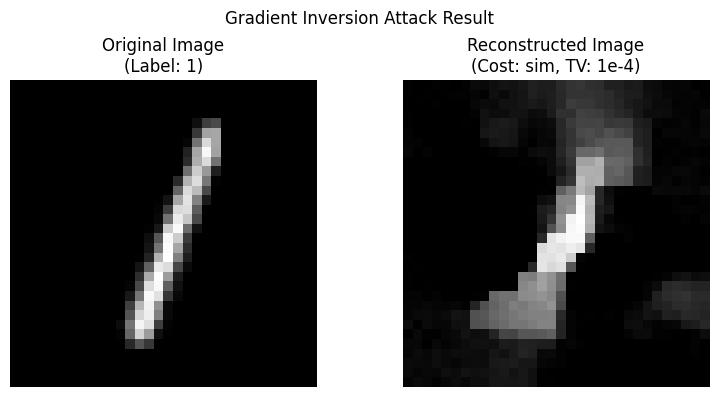

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, AveragePooling2D, Flatten, Dense
import numpy as np
import time
import matplotlib.pyplot as plt

# --- 1. Gradient Inversion Attack Components (TensorFlow Adaptation of InverseFed) ---

def total_variation_loss(img):
    """Calculates the Total Variation regularization term."""
    # TV is typically calculated only on the spatial dimensions (H, W) for each channel (C)
    # tf.image.total_variation calculates TV loss over the last two dimensions.
    return tf.reduce_sum(tf.image.total_variation(img))

def reconstruction_costs_tf(trial_gradients, input_gradient, cost_fn='sim'):
    """
    Calculates the distance between generated gradients (trial_gradients)
    and the intercepted client gradient (input_gradient).

    This mimics the L2 and Cosine Similarity (sim) costs from the inversefed paper.
    Weights are assumed to be 'equal' (i.e., every layer contributes equally).
    """
    if cost_fn == 'l2':
        total_costs = tf.constant(0.0)
        for trial_grad, input_grad in zip(trial_gradients, input_gradient):
            # L2 squared distance: sum((g_trial - g_input)^2)
            cost = tf.reduce_sum(tf.square(trial_grad - input_grad))
            total_costs += cost
        return total_costs

    elif cost_fn == 'sim':
        # Cosine Similarity-based cost: 1 - CosSim(g_trial, g_input)

        # 1. Flatten all gradients into a single large vector for both sets
        trial_flat = tf.concat([tf.reshape(g, [-1]) for g in trial_gradients], axis=0)
        input_flat = tf.concat([tf.reshape(g, [-1]) for g in input_gradient], axis=0)

        # 2. Calculate Dot Product and Norms
        dot_product = tf.reduce_sum(trial_flat * input_flat)
        norm_trial = tf.sqrt(tf.reduce_sum(tf.square(trial_flat)))
        norm_input = tf.sqrt(tf.reduce_sum(tf.square(input_flat)))

        # 3. Calculate Cosine Similarity
        # Add epsilon for numerical stability when dividing by norm_trial * norm_input
        cosine_similarity = dot_product / (norm_trial * norm_input + tf.keras.backend.epsilon())

        # 4. Cost is 1 - Cosine Similarity (minimizing this means maximizing similarity)
        return 1.0 - cosine_similarity

    else:
        raise ValueError(f"Unknown cost function: {cost_fn}")


class TensorFlowGradientReconstructor:
    """
    Reconstructs an image from client gradients using TensorFlow/Keras,
    mimicking the optimization approach of inversefed.
    """
    def __init__(self, target_model, config=None):
        self.target_model = target_model
        self.config = {
            'lr': 0.1,
            'optim': 'Adam',
            'max_iterations': 4800,
            'total_variation': 1e-4, # Reduced TV loss for better convergence
            'cost_fn': 'sim',
            'init': 'randn',
            'boxed': True, # Clip to [0, 1] range
        }
        if config:
            self.config.update(config)

        # The loss function used by the client for the original gradient computation
        self.client_loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(reduction=tf.keras.losses.Reduction.SUM)

    def _init_images(self, img_shape):
        """Initializes the image tensor based on config['init']"""
        # img_shape should be (H, W, C)
        if self.config['init'] == 'randn':
            # Initialize with random noise
            x = tf.random.normal((1, *img_shape), dtype=tf.float32)
        elif self.config['init'] == 'zeros':
            x = tf.zeros((1, *img_shape), dtype=tf.float32)
        else: # 'rand'
            # Initialize with uniform random noise in range [-1, 1]
            x = (tf.random.uniform((1, *img_shape), dtype=tf.float32) - 0.5) * 2

        # The image must be a trainable variable for the optimizer to update it
        return tf.Variable(x, trainable=True)

    def reconstruct(self, input_gradient, client_data_shape, dummy_label=None):
        """
        Main reconstruction loop.

        :param input_gradient: The list of TensorFlow tensors (the intercepted gradient).
        :param client_data_shape: The shape of the expected image (H, W, C).
        :param dummy_label: The label to use for the loss (e.g., the true label if known).
        """
        print(f"\n--- Starting Gradient Inversion Attack ---")
        start_time = time.time()

        # 1. Image Initialization
        x = self._init_images(img_shape=client_data_shape)

        # 2. Dummy Label Setup
        # If the label is not provided, we must guess it. For simplicity, we assume
        # a placeholder label (e.g., class 0) since we don't implement the iDLG trick.
        if dummy_label is None:
            # Assumes a batch size of 1
            dummy_label = tf.constant([0], dtype=tf.int32)

        # 3. Optimizer Setup
        # We optimize the *image variable x*, not the model weights
        optimizer = tf.optimizers.Adam(learning_rate=self.config['lr'])
        max_iterations = self.config['max_iterations']

        print(f"Attack Config: Iterations={max_iterations}, LR={self.config['lr']}, Cost={self.config['cost_fn']}, TV={self.config['total_variation']}")

        # 4. Reconstruction Loop
        for iteration in range(max_iterations):
            with tf.GradientTape() as tape_outer:
                # tape_outer tracks the image 'x' to compute d(RecLoss) / d(x)

                with tf.GradientTape() as tape_inner:
                    # tape_inner tracks the model's trainable variables to compute d(Loss) / d(w)

                    # Model's output for the reconstructed image
                    # Target model weights are kept constant (training=False)
                    logits = self.target_model(x, training=False)

                    # Calculate the client's loss on the reconstructed image/label pair
                    client_loss = self.client_loss_fn(dummy_label, logits)

                # Calculate the *generated* gradients w.r.t. model weights (w)
                # This is the core of the attack: Gradient(Loss(x,y,w), w)
                generated_gradients = tape_inner.gradient(client_loss, self.target_model.trainable_variables)

                # Calculate the Reconstruction Loss (Distance between generated and target gradients)
                rec_loss = reconstruction_costs_tf(generated_gradients, input_gradient, cost_fn=self.config['cost_fn'])

                # Add Total Variation regularization
                if self.config['total_variation'] > 0:
                    tv_loss = total_variation_loss(x)
                    rec_loss += self.config['total_variation'] * tv_loss

            # 5. Update the Image (x)
            # The gradients are w.r.t the image 'x'
            image_grad = tape_outer.gradient(rec_loss, x)

            # Apply update to the image 'x'
            optimizer.apply_gradients(zip([image_grad], [x]))

            # 6. Box Constraint (Clipping)
            if self.config['boxed']:
                # Clips x to the valid range for MNIST (0.0 to 1.0)
                x.assign(tf.clip_by_value(x, 0.0, 1.0))

            if (iteration + 1) % 500 == 0:
                print(f'Iteration: {iteration + 1}/{max_iterations}. Rec. loss: {rec_loss.numpy():.6f}.')

        print(f'Total time: {time.time()-start_time:.2f} seconds.')
        # Return the final reconstructed image array (remove the batch dimension)
        return x.numpy()[0]


# --- 2. Original FL Setup (from train.txt) ---

# Dataset (MNIST) Loading and Preprocessing
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, y_train = x_train[:2000], y_train[:2000]

# Normalize to [0, 1] range for the attack's boxed constraint
x_train, x_test = x_train.astype("float32") / 255.0, x_test.astype("float32") / 255.0
y_train, y_test = y_train.flatten(), y_test.flatten()

def prep(x):
    # (N, 28,28,1)
    x = np.expand_dims(x, axis=-1)
    # Resize to 32x32
    x = tf.image.resize(x, [32, 32]).numpy()
    # replicate channel to make 3 channels (LeNet-5 requires 3 channels sometimes)
    x = np.repeat(x, 3, axis=-1)
    return x

x_train = prep(x_train)
x_test = prep(x_test)

# Split Data among clients
num_clients = 2
data_per_client = len(x_train) // num_clients
client_data = [(x_train[i * data_per_client:(i + 1) * data_per_client],
                y_train[i * data_per_client:(i + 1) * data_per_client])
               for i in range(num_clients)]

num_classes = 10
batch_size = 8
epochs = 5

# LeNet Model Definition
def build_model(input_shape=(32, 32, 3), num_classes=10):
    with tf.device('/cpu:0'):
        inputs = Input(shape=input_shape)
        # C1: 6 filters, 5x5, tanh
        x = Conv2D(6, (5, 5), activation='tanh', padding='valid', name='C1')(inputs)
        # S2: Average pooling 2x2, stride 2
        x = AveragePooling2D(pool_size=(2, 2), name='S2')(x)
        # C3: 16 filters, 5x5, tanh
        x = Conv2D(16, (5, 5), activation='tanh', padding='valid', name='C3')(x)
        # S4: Average pooling 2x2, stride 2
        x = AveragePooling2D(pool_size=(2, 2), name='S4')(x)
        # Flatten
        x = Flatten(name='Flatten')(x)
        # F5: Dense 120, tanh
        x = Dense(120, activation='tanh', name='F5')(x)
        # F6: Dense 84, tanh
        x = Dense(84, activation='tanh', name='F6')(x)
        # Output: Softmax for 10 classes
        outputs = Dense(num_classes, activation='softmax', name='Output')(x)

    return Model(inputs, outputs, name='LeNet')

def evaluate_global_model(model):
    """Evaluates the model on the test set."""
    batch_size_eval = 512
    num_samples = len(x_test)
    preds = []
    for i in range(0, num_samples, batch_size_eval):
        batch_x = x_test[i:i+batch_size_eval]
        logits = model(batch_x, training=False)
        batch_preds = tf.argmax(logits, axis=1)
        preds.extend(batch_preds.numpy())
    preds = tf.convert_to_tensor(preds, dtype=tf.int32) # Cast predictions to int32

    # FIX: Cast y_test to int32 to match preds
    y_test_cast = tf.cast(y_test, tf.int32)

    acc = tf.reduce_mean(tf.cast(tf.equal(preds, y_test_cast), tf.float32))
    print(f"Global Test Accuracy: {acc.numpy():.4f}")

# FedAvg Helpers
def average_trainable_weights_weighted(model_list, sample_counts):
    new_weights = []
    total_samples = sum(sample_counts)
    for weights in zip(*[model.trainable_weights for model in model_list]):
        weighted_sum = sum(w.numpy() * (count / total_samples)
                           for w, count in zip(weights, sample_counts))
        new_weights.append(weighted_sum)
    return new_weights

def set_trainable_weights(model, new_weights):
    for var, new in zip(model.trainable_weights, new_weights):
        var.assign(new)

# --- 3. FL Training with Gradient Capture ---

# Initialize global model (which clients start with)
initial_global_model = build_model()
initial_global_model.build(input_shape=(None, 32, 32, 3)) # Explicitly build the model

models = []
for _ in range(num_clients):
    model = build_model()
    # Set initial weights to be the same as the global model
    model.set_weights(initial_global_model.get_weights())
    models.append(model)

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=1000,
    decay_rate=0.9
)
optimizers = [tf.keras.optimizers.Adam(learning_rate=lr_schedule) for _ in range(num_clients)]

# Variables to store the target for the attack
target_client_gradient = None
target_model_for_attack = None
target_true_data = None
target_true_label = None

print("Starting Federated Learning Simulation...")

for epoch in range(epochs):
    print(f"\n🌀 Epoch {epoch + 1}/{epochs}")
    epoch_client_grads = []

    for client_id, (x_client, y_client) in enumerate(client_data):
        start_time = time.time()

        train_ds = tf.data.Dataset.from_tensor_slices((x_client, y_client)).shuffle(1000).batch(batch_size)
        model = models[client_id]

        for step, (x_batch, y_batch) in enumerate(train_ds):

            # --- CAPTURE THE TARGET GRADIENT ---
            if epoch == 0 and client_id == 0 and step == 0:
                # Store the model state *before* this gradient update (which is the current model state)
                target_model_for_attack = build_model()
                target_model_for_attack.set_weights(model.get_weights())
                target_true_data = x_batch[0].numpy() # First image in the batch
                target_true_label = y_batch[0].numpy() # First label in the batch

            with tf.GradientTape() as tape:
                logits = model(x_batch, training=True)
                loss = loss_fn(y_batch, logits)
                acc = tf.reduce_mean(tf.cast(tf.equal(tf.argmax(logits, axis=1), tf.cast(y_batch, tf.int64)), tf.float32))

            grads = tape.gradient(loss, model.trainable_variables)

            # --- CAPTURE THE TARGET GRADIENT (store the computed gradient) ---
            if epoch == 0 and client_id == 0 and step == 0:
                # Deep copy the gradients list
                target_client_gradient = [tf.identity(g) for g in grads]
                print(f"Target Gradient captured (Client {client_id}, Epoch {epoch+1}, Step {step}).")

            epoch_client_grads.append(grads)
            optimizers[client_id].apply_gradients(zip(grads, model.trainable_variables))

            if step % 100 == 0 and step > 0:
                print(f"Client {client_id}, Step {step}, Loss: {loss.numpy():.4f}, Accuracy: {acc.numpy():.4f}")

        end_time = time.time()
        print(f"Client {client_id} finished. Time taken: {end_time - start_time:.2f}s")


    # FedAvg: Compute aggregated weights and update all models
    sample_counts = [len(data[0]) for data in client_data]
    avg_weights = average_trainable_weights_weighted(models, sample_counts)
    for model in models:
        set_trainable_weights(model, avg_weights)

    evaluate_global_model(models[0])

print("\nFederated Learning Simulation Complete.")


# --- 4. Standalone Gradient Inversion Attack Execution ---

def run_gradient_inversion_attack(target_model, target_gradient, true_image, true_label):
    """
    Executes the gradient inversion attack using the captured state.
    """
    if target_model is None or target_gradient is None:
        print("Error: Target model or gradient not captured during FL training.")
        return

    # The shape of the input data (H, W, C)
    client_data_shape = true_image.shape

    # Run the reconstructor
    reconstructor = TensorFlowGradientReconstructor(
        target_model=target_model,
        config={'total_variation': 1e-4, 'max_iterations': 3000} # Use fewer iterations for speed
    )

    # For the attack, we use the gradient, the image shape, and the true label
    # (if the attacker knows it, which is the iDLG assumption for simplicity)
    reconstructed_image = reconstructor.reconstruct(
        input_gradient=target_gradient,
        client_data_shape=client_data_shape,
        # We use a batch size of 1 for the attack reconstruction, so we pass the label as a list
        dummy_label=tf.constant([true_label], dtype=tf.int32)
    )

    # --- Visualization ---
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    # True Image (Reshape to remove 3 channels for visualization if it's grayscale)
    if true_image.shape[-1] == 3:
        # Assuming the original MNIST image was grayscale (1 channel)
        true_image_display = true_image[:, :, 0]
        reconstructed_image_display = reconstructed_image[:, :, 0]
    else:
        true_image_display = true_image
        reconstructed_image_display = reconstructed_image

    axes[0].imshow(true_image_display, cmap='gray')
    axes[0].set_title(f'Original Image\n(Label: {true_label})')
    axes[0].axis('off')

    axes[1].imshow(reconstructed_image_display, cmap='gray')
    axes[1].set_title(f'Reconstructed Image\n(Cost: sim, TV: 1e-4)')
    axes[1].axis('off')

    plt.suptitle("Gradient Inversion Attack Result")
    plt.tight_layout()
    plt.show()

# Execute the attack after the FL simulation finishes
if target_client_gradient is not None:
    print("\n\n#####################################################")
    print("Executing standalone Gradient Inversion Attack...")
    print("#####################################################")
    # true_image and true_label are the data/label that generated the target_client_gradient
    run_gradient_inversion_attack(
        target_model=target_model_for_attack,
        target_gradient=target_client_gradient,
        true_image=target_true_data,
        true_label=target_true_label
    )
else:
    print("\nAttack cannot be run: Target gradient was not successfully captured.")



#####################################################
Executing standalone Gradient Inversion Attack...
#####################################################

--- Starting Gradient Inversion Attack ---
Attack Config: Iterations=3000, LR=0.1, Cost=sim, TV=0.0001
Iteration: 500/3000. Rec. loss: 0.154990.
Iteration: 1000/3000. Rec. loss: 0.155118.
Iteration: 1500/3000. Rec. loss: 0.155115.
Iteration: 2000/3000. Rec. loss: 0.155142.
Iteration: 2500/3000. Rec. loss: 0.155159.
Iteration: 3000/3000. Rec. loss: 0.155170.
Total time: 185.31 seconds.


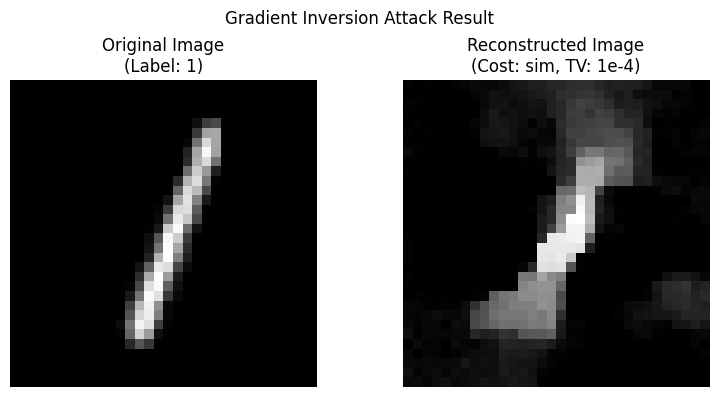

In [ ]:
# Execute the attack after the FL simulation finishes
if target_client_gradient is not None:
    print("\n\n#####################################################")
    print("Executing standalone Gradient Inversion Attack...")
    print("#####################################################")
    # true_image and true_label are the data/label that generated the target_client_gradient
    run_gradient_inversion_attack(
        target_model=target_model_for_attack,
        target_gradient=target_client_gradient,
        true_image=target_true_data,
        true_label=target_true_label
    )
else:
    print("\nAttack cannot be run: Target gradient was not successfully captured.")

In [ ]:
#Stable Version
#Attempt 5:


import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, AveragePooling2D, Flatten, Dense
import numpy as np
import time
import matplotlib.pyplot as plt



# --- 2. Original FL Setup ---

# Dataset (MNIST) Loading and Preprocessing
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
#x_train, y_train = x_train[:2000], y_train[:2000]
x_train, y_train = x_train[:8], y_train[:8]

# Normalize to [0, 1] range for the attack's boxed constraint
x_train, x_test = x_train.astype("float32") / 255.0, x_test.astype("float32") / 255.0
y_train, y_test = y_train.flatten(), y_test.flatten()

def prep(x):
    # (N, 28,28,1)
    x = np.expand_dims(x, axis=-1)
    # Resize to 32x32
    x = tf.image.resize(x, [32, 32]).numpy()
    # replicate channel to make 3 channels (LeNet-5 requires 3 channels sometimes)
    x = np.repeat(x, 3, axis=-1)
    return x

x_train = prep(x_train)
x_test = prep(x_test)

# Split Data among clients
num_clients = 2
data_per_client = len(x_train) // num_clients
client_data = [(x_train[i * data_per_client:(i + 1) * data_per_client],
                y_train[i * data_per_client:(i + 1) * data_per_client])
               for i in range(num_clients)]

num_classes = 10
batch_size = 8
epochs = 20

# LeNet Model Definition
def build_model(input_shape=(32, 32, 3), num_classes=10):
    with tf.device('/cpu:0'):
        inputs = Input(shape=input_shape)
        # C1: 6 filters, 5x5, tanh
        x = Conv2D(6, (5, 5), activation='tanh', padding='valid', name='C1')(inputs)
        # S2: Average pooling 2x2, stride 2
        x = AveragePooling2D(pool_size=(2, 2), name='S2')(x)
        # C3: 16 filters, 5x5, tanh
        x = Conv2D(16, (5, 5), activation='tanh', padding='valid', name='C3')(x)
        # S4: Average pooling 2x2, stride 2
        x = AveragePooling2D(pool_size=(2, 2), name='S4')(x)
        # Flatten
        x = Flatten(name='Flatten')(x)
        # F5: Dense 120, tanh
        x = Dense(120, activation='tanh', name='F5')(x)
        # F6: Dense 84, tanh
        x = Dense(84, activation='tanh', name='F6')(x)
        # Output: Softmax for 10 classes
        outputs = Dense(num_classes, activation='softmax', name='Output')(x)

    return Model(inputs, outputs, name='LeNet')

def evaluate_global_model(model):
    """Evaluates the model on the test set."""
    batch_size_eval = 512
    num_samples = len(x_test)
    preds = []
    for i in range(0, num_samples, batch_size_eval):
        batch_x = x_test[i:i+batch_size_eval]
        logits = model(batch_x, training=False)
        batch_preds = tf.argmax(logits, axis=1)
        preds.extend(batch_preds.numpy())
    preds = tf.convert_to_tensor(preds, dtype=tf.int32) # Cast predictions to int32

    # FIX: Cast y_test to int32 to match preds
    y_test_cast = tf.cast(y_test, tf.int32)

    acc = tf.reduce_mean(tf.cast(tf.equal(preds, y_test_cast), tf.float32))
    print(f"Global Test Accuracy: {acc.numpy():.4f}")

# FedAvg Helpers
def average_trainable_weights_weighted(model_list, sample_counts):
    new_weights = []
    total_samples = sum(sample_counts)
    for weights in zip(*[model.trainable_weights for model in model_list]):
        weighted_sum = sum(w.numpy() * (count / total_samples)
                           for w, count in zip(weights, sample_counts))
        new_weights.append(weighted_sum)
    return new_weights

def set_trainable_weights(model, new_weights):
    for var, new in zip(model.trainable_weights, new_weights):
        var.assign(new)

# --- 3. FL Training with Gradient Capture ---

# Initialize global model (which clients start with)
initial_global_model = build_model()
initial_global_model.build(input_shape=(None, 32, 32, 3)) # Explicitly build the model

models = []
for _ in range(num_clients):
    model = build_model()
    # Set initial weights to be the same as the global model
    model.set_weights(initial_global_model.get_weights())
    models.append(model)

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=1000,
    decay_rate=0.9
)
optimizers = [tf.keras.optimizers.Adam(learning_rate=lr_schedule) for _ in range(num_clients)]

# Variables to store the target for the attack (updated to handle batches)
target_client_gradient = None
target_client_gradient_1 = None
target_model_for_attack = None
target_true_data_batch = None  # Stores the entire batch of 8 images
target_true_label_batch = None # Stores the entire batch of 8 labels

print("Starting Federated Learning Simulation...")

for epoch in range(epochs):
    print(f"\n🌀 Epoch {epoch + 1}/{epochs}")
    epoch_client_grads = []

    for client_id, (x_client, y_client) in enumerate(client_data):
        start_time = time.time()

        train_ds = tf.data.Dataset.from_tensor_slices((x_client, y_client)).shuffle(1000).batch(batch_size)
        model = models[client_id]

        for step, (x_batch, y_batch) in enumerate(train_ds):

            # --- CAPTURE THE TARGET GRADIENT ---
            if epoch == 0 and client_id == 0 and step == 0:
                # Store the model state *before* this gradient update (which is the current model state)
                target_model_for_attack = build_model()
                target_model_for_attack.set_weights(model.get_weights())

                # CAPTURE THE ENTIRE BATCH OF TRUE DATA AND LABELS
                target_true_data_batch = x_batch.numpy()
                target_true_label_batch = y_batch.numpy()

            with tf.GradientTape() as tape:
                logits = model(x_batch, training=True)
                loss = loss_fn(y_batch, logits)
                acc = tf.reduce_mean(tf.cast(tf.equal(tf.argmax(logits, axis=1), tf.cast(y_batch, tf.int64)), tf.float32))




            # --- Example of DP-like mechanism ---
            l2_norm_clip = 1.0  # Clipping threshold
            noise_multiplier = 0.01 # Standard deviation of noise


            # 1. Calculate Gradients
            grads = tape.gradient(loss, model.trainable_variables)

            # 2. L2 Norm Clipping
            #grads, _ = tf.clip_by_global_norm(grads, l2_norm_clip)

            # 3. Add Gaussian Noise
            #grads = [g + tf.random.normal(g.shape, stddev=noise_multiplier) for g in grads]

            # --- CAPTURE THE TARGET GRADIENT (store the computed gradient) ---

            if epoch == 0 and client_id == 0 and step == 0:
                # Deep copy the gradients list
                target_client_gradient = [tf.identity(g) for g in grads]
                print(f"Target Gradient captured (Client {client_id}, Epoch {epoch+1}, Step {step}). Batch size: {len(x_batch)}.")


            if epoch == 19 and client_id == 0 and step == 0:
                # Deep copy the gradients list
                target_client_gradient_1 = [tf.identity(g) for g in grads]
                print(f"Target Gradient captured (Client {client_id}, Epoch {epoch+1}, Step {step}). Batch size: {len(x_batch)}.")


            epoch_client_grads.append(grads)
            optimizers[client_id].apply_gradients(zip(grads, model.trainable_variables))

            if step % 100 == 0 and step > 0:
                print(f"Client {client_id}, Step {step}, Loss: {loss.numpy():.4f}, Accuracy: {acc.numpy():.4f}")

        end_time = time.time()
        print(f"Client {client_id} finished. Time taken: {end_time - start_time:.2f}s")


    # FedAvg: Compute aggregated weights and update all models
    sample_counts = [len(data[0]) for data in client_data]
    avg_weights = average_trainable_weights_weighted(models, sample_counts)
    for model in models:
        set_trainable_weights(model, avg_weights)

    evaluate_global_model(models[0])

print("\nFederated Learning Simulation Complete.")


Starting Federated Learning Simulation...

🌀 Epoch 1/20
Target Gradient captured (Client 0, Epoch 1, Step 0). Batch size: 4.
Client 0 finished. Time taken: 0.13s
Client 1 finished. Time taken: 0.10s
Global Test Accuracy: 0.2001

🌀 Epoch 2/20
Client 0 finished. Time taken: 0.08s
Client 1 finished. Time taken: 0.08s
Global Test Accuracy: 0.1791

🌀 Epoch 3/20
Client 0 finished. Time taken: 0.08s
Client 1 finished. Time taken: 0.08s
Global Test Accuracy: 0.1915

🌀 Epoch 4/20
Client 0 finished. Time taken: 0.08s
Client 1 finished. Time taken: 0.08s
Global Test Accuracy: 0.2322

🌀 Epoch 5/20
Client 0 finished. Time taken: 0.08s
Client 1 finished. Time taken: 0.09s
Global Test Accuracy: 0.2651

🌀 Epoch 6/20
Client 0 finished. Time taken: 0.08s
Client 1 finished. Time taken: 0.09s
Global Test Accuracy: 0.2885

🌀 Epoch 7/20
Client 0 finished. Time taken: 0.09s
Client 1 finished. Time taken: 0.08s
Global Test Accuracy: 0.3054

🌀 Epoch 8/20
Client 0 finished. Time taken: 0.08s
Client 1 finished. 

In [ ]:
#Stable Version

# --- 1. Gradient Inversion Attack Components (TensorFlow Adaptation of InverseFed) ---

def total_variation_loss(img):
    """Calculates the Total Variation regularization term."""
    # TV is typically calculated only on the spatial dimensions (H, W) for each channel (C)
    # tf.image.total_variation calculates TV loss over the last two dimensions.
    return tf.reduce_sum(tf.image.total_variation(img))

def reconstruction_costs_tf(trial_gradients, input_gradient, cost_fn='sim'):
    """
    Calculates the distance between generated gradients (trial_gradients)
    and the intercepted client gradient (input_gradient).

    This mimics the L2 and Cosine Similarity (sim) costs from the inversefed paper.
    Weights are assumed to be 'equal' (i.e., every layer contributes equally).
    """
    if cost_fn == 'l2':
        total_costs = tf.constant(0.0)
        for trial_grad, input_grad in zip(trial_gradients, input_gradient):
            # L2 squared distance: sum((g_trial - g_input)^2)
            cost = tf.reduce_sum(tf.square(trial_grad - input_grad))
            total_costs += cost
        return total_costs

    elif cost_fn == 'sim':
        # Cosine Similarity-based cost: 1 - CosSim(g_trial, g_input)

        # 1. Flatten all gradients into a single large vector for both sets
        trial_flat = tf.concat([tf.reshape(g, [-1]) for g in trial_gradients], axis=0)
        input_flat = tf.concat([tf.reshape(g, [-1]) for g in input_gradient], axis=0)

        # 2. Calculate Dot Product and Norms
        dot_product = tf.reduce_sum(trial_flat * input_flat)
        norm_trial = tf.sqrt(tf.reduce_sum(tf.square(trial_flat)))
        norm_input = tf.sqrt(tf.reduce_sum(tf.square(input_flat)))

        # 3. Calculate Cosine Similarity
        # Add epsilon for numerical stability when dividing by norm_trial * norm_input
        cosine_similarity = dot_product / (norm_trial * norm_input + tf.keras.backend.epsilon())

        # 4. Cost is 1 - Cosine Similarity (minimizing this means maximizing similarity)
        return 1.0 - cosine_similarity

    else:
        raise ValueError(f"Unknown cost function: {cost_fn}")


class TensorFlowGradientReconstructor:
    """
    Reconstructs an image from client gradients using TensorFlow/Keras,
    mimicking the optimization approach of inversefed.
    """
    def __init__(self, target_model, num_images, config=None):
        self.target_model = target_model
        self.num_images = num_images # The batch size for reconstruction
        self.config = {
            'lr': 0.01,
            'optim': 'Adam',
            'max_iterations': 4800,
            'total_variation': 1e-4, # Reduced TV loss for better convergence
            'cost_fn': 'sim',
            'init': 'randn',
            'boxed': True, # Clip to [0, 1] range
        }
        if config:
            self.config.update(config)

        # The loss function used by the client for the original gradient computation
        # Reduction is SUM because the gradient is the sum of gradients over the batch.
        self.client_loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(reduction=tf.keras.losses.Reduction.SUM)

    def _init_images(self, img_shape):
        """Initializes the image tensor based on config['init'] with batch size self.num_images."""
        # img_shape should be (H, W, C)
        shape_with_batch = (self.num_images, *img_shape)

        if self.config['init'] == 'randn':
            # Initialize with random noise
            x = tf.random.normal(shape_with_batch, dtype=tf.float32)
        elif self.config['init'] == 'zeros':
            x = tf.zeros(shape_with_batch, dtype=tf.float32)
        else: # 'rand'
            # Initialize with uniform random noise in range [-1, 1]
            x = (tf.random.uniform(shape_with_batch, dtype=tf.float32) - 0.5) * 2

        # The image must be a trainable variable for the optimizer to update it
        return tf.Variable(x, trainable=True)

    def reconstruct(self, input_gradient, client_data_shape, dummy_labels):
        """
        Main reconstruction loop.

        :param input_gradient: The list of TensorFlow tensors (the intercepted batch gradient).
        :param client_data_shape: The shape of a single expected image (H, W, C).
        :param dummy_labels: The labels (tf.Tensor) corresponding to the batch (size=num_images).
        """
        print(f"\n--- Starting Gradient Inversion Attack (Batch Size: {self.num_images}) ---")
        start_time = time.time()

        # 1. Image Initialization (Batch size: self.num_images)
        x = self._init_images(img_shape=client_data_shape)

        # 2. Optimizer Setup
        # We optimize the *image variable x*, not the model weights
        optimizer = tf.optimizers.Adam(learning_rate=self.config['lr'])
        max_iterations = self.config['max_iterations']

        print(f"Attack Config: Iterations={max_iterations}, LR={self.config['lr']}, Cost={self.config['cost_fn']}, TV={self.config['total_variation']}")

        # 3. Reconstruction Loop
        for iteration in range(max_iterations):
            with tf.GradientTape() as tape_outer:
                # tape_outer tracks the image 'x' to compute d(RecLoss) / d(x)

                with tf.GradientTape() as tape_inner:
                    # tape_inner tracks the model's trainable variables to compute d(Loss) / d(w)

                    # Model's output for the reconstructed image batch
                    logits = self.target_model(x, training=False)

                    # Calculate the client's loss on the reconstructed image/label batch
                    client_loss = self.client_loss_fn(dummy_labels, logits)

                # Calculate the *generated* gradients w.r.t. model weights (w)
                generated_gradients = tape_inner.gradient(client_loss, self.target_model.trainable_variables)

                # Calculate the Reconstruction Loss (Distance between generated and target gradients)
                rec_loss = reconstruction_costs_tf(generated_gradients, input_gradient, cost_fn=self.config['cost_fn'])

                # Add Total Variation regularization
                if self.config['total_variation'] > 0:
                    tv_loss = total_variation_loss(x)
                    rec_loss += self.config['total_variation'] * tv_loss

            # 4. Update the Image (x)
            image_grad = tape_outer.gradient(rec_loss, x)

            # Apply update to the image 'x'
            optimizer.apply_gradients(zip([image_grad], [x]))

            # 5. Box Constraint (Clipping)
            if self.config['boxed']:
                # Clips x to the valid range for MNIST (0.0 to 1.0)
                x.assign(tf.clip_by_value(x, 0.0, 1.0))

            if (iteration + 1) % 500 == 0:
                print(f'Iteration: {iteration + 1}/{max_iterations}. Rec. loss: {rec_loss.numpy():.6f}.')

        print(f'Total time: {time.time()-start_time:.2f} seconds.')
        # Return the final reconstructed image array (remove the batch dimension)
        return x.numpy()






# --- 4. Standalone Gradient Inversion Attack Execution ---

def run_gradient_inversion_attack(target_model, target_gradient, true_data_batch, true_label_batch):
    """
    Executes the gradient inversion attack using the captured batch state and visualizes the results.
    """
    if target_model is None or target_gradient is None:
        print("Error: Target model or gradient not captured during FL training.")
        return

    num_images = len(true_data_batch) # Should be 8
    # The shape of a single input data point (H, W, C)
    client_data_shape = true_data_batch.shape[1:]

    # Run the reconstructor
    reconstructor = TensorFlowGradientReconstructor(
        target_model=target_model,
        num_images=num_images, # Pass the batch size to the reconstructor
        config={'total_variation': 1e-5, 'max_iterations': 4800}
    )

    # Pass the entire true label batch to the reconstructor
    reconstructed_image_batch = reconstructor.reconstruct(
        input_gradient=target_gradient,
        client_data_shape=client_data_shape,
        dummy_labels=tf.constant(true_label_batch, dtype=tf.int32)
    )

    # --- Visualization: 2 rows x num_images columns ---
    fig, axes = plt.subplots(2, num_images, figsize=(num_images * 2, 4))

    for i in range(num_images):
        # Prepare image for display (assuming grayscale for MNIST)
        true_img_display = true_data_batch[i][:, :, 0] if true_data_batch.shape[-1] == 3 else true_data_batch[i]
        rec_img_display = reconstructed_image_batch[i][:, :, 0] if reconstructed_image_batch.shape[-1] == 3 else reconstructed_image_batch[i]

        # Top row: Original Images
        axes[0, i].imshow(true_img_display, cmap='gray')
        axes[0, i].set_title(f'True {i} ({true_label_batch[i]})', fontsize=10)
        axes[0, i].axis('off')

        # Bottom row: Reconstructed Images
        axes[1, i].imshow(rec_img_display, cmap='gray')
        axes[1, i].set_title(f'Rec {i}', fontsize=10)
        axes[1, i].axis('off')

    axes[0, 0].text(-2, 16, "Original", rotation=90, va='center', ha='right', fontsize=12, fontweight='bold')
    axes[1, 0].text(-2, 16, "Reconstructed", rotation=90, va='center', ha='right', fontsize=12, fontweight='bold')


    plt.suptitle("Gradient Inversion Attack Result (Batch Reconstruction)", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()





# Execute the attack after the FL simulation finishes
if target_client_gradient is not None:
    print("\n\n#####################################################")
    print("Executing standalone Gradient Inversion Attack...")
    print("#####################################################")
    # true_data_batch and true_label_batch are the batch data/labels that generated the target_client_gradient
    run_gradient_inversion_attack(
        target_model=target_model_for_attack,
        target_gradient=target_client_gradient,
        true_data_batch=target_true_data_batch,
        true_label_batch=target_true_label_batch
    )
else:
    print("\nAttack cannot be run: Target gradient was not successfully captured.")

NameError: name 'target_client_gradient' is not defined

In [ ]:
#Stable Version
#Attempt 5 extended:


import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, AveragePooling2D, Flatten, Dense
import numpy as np
import time
import matplotlib.pyplot as plt



# --- 2. Original FL Setup ---

# Dataset (MNIST) Loading and Preprocessing
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
#x_train, y_train = x_train[:2000], y_train[:2000]
x_train, y_train = x_train[:16], y_train[:16]

# Normalize to [0, 1] range for the attack's boxed constraint
x_train, x_test = x_train.astype("float32") / 255.0, x_test.astype("float32") / 255.0
y_train, y_test = y_train.flatten(), y_test.flatten()

def prep(x):
    # (N, 28,28,1)
    x = np.expand_dims(x, axis=-1)
    # Resize to 32x32
    x = tf.image.resize(x, [32, 32]).numpy()
    # replicate channel to make 3 channels (LeNet-5 requires 3 channels sometimes)
    x = np.repeat(x, 3, axis=-1)
    return x

x_train = prep(x_train)
x_test = prep(x_test)

# Split Data among clients
num_clients = 2
data_per_client = len(x_train) // num_clients
client_data = [(x_train[i * data_per_client:(i + 1) * data_per_client],
                y_train[i * data_per_client:(i + 1) * data_per_client])
               for i in range(num_clients)]

num_classes = 10
batch_size = 8
epochs = 100

# LeNet Model Definition
def build_model(input_shape=(32, 32, 3), num_classes=10):
    with tf.device('/cpu:0'):
        inputs = Input(shape=input_shape)
        # C1: 6 filters, 5x5, tanh
        x = Conv2D(6, (5, 5), activation='tanh', padding='valid', name='C1')(inputs)
        # S2: Average pooling 2x2, stride 2
        x = AveragePooling2D(pool_size=(2, 2), name='S2')(x)
        # C3: 16 filters, 5x5, tanh
        x = Conv2D(16, (5, 5), activation='tanh', padding='valid', name='C3')(x)
        # S4: Average pooling 2x2, stride 2
        x = AveragePooling2D(pool_size=(2, 2), name='S4')(x)
        # Flatten
        x = Flatten(name='Flatten')(x)
        # F5: Dense 120, tanh
        x = Dense(120, activation='tanh', name='F5')(x)
        # F6: Dense 84, tanh
        x = Dense(84, activation='tanh', name='F6')(x)
        # Output: Softmax for 10 classes
        outputs = Dense(num_classes, activation='softmax', name='Output')(x)

    return Model(inputs, outputs, name='LeNet')

def evaluate_global_model(model):
    """Evaluates the model on the test set."""
    batch_size_eval = 512
    num_samples = len(x_test)
    preds = []
    for i in range(0, num_samples, batch_size_eval):
        batch_x = x_test[i:i+batch_size_eval]
        logits = model(batch_x, training=False)
        batch_preds = tf.argmax(logits, axis=1)
        preds.extend(batch_preds.numpy())
    preds = tf.convert_to_tensor(preds, dtype=tf.int32) # Cast predictions to int32

    # FIX: Cast y_test to int32 to match preds
    y_test_cast = tf.cast(y_test, tf.int32)

    acc = tf.reduce_mean(tf.cast(tf.equal(preds, y_test_cast), tf.float32))
    print(f"Global Test Accuracy: {acc.numpy():.4f}")

# FedAvg Helpers
def average_trainable_weights_weighted(model_list, sample_counts):
    new_weights = []
    total_samples = sum(sample_counts)
    for weights in zip(*[model.trainable_weights for model in model_list]):
        weighted_sum = sum(w.numpy() * (count / total_samples)
                           for w, count in zip(weights, sample_counts))
        new_weights.append(weighted_sum)
    return new_weights

def set_trainable_weights(model, new_weights):
    for var, new in zip(model.trainable_weights, new_weights):
        var.assign(new)

# --- 3. FL Training with Gradient Capture ---

# Initialize global model (which clients start with)
initial_global_model = build_model()
initial_global_model.build(input_shape=(None, 32, 32, 3)) # Explicitly build the model

models = []
for _ in range(num_clients):
    model = build_model()
    # Set initial weights to be the same as the global model
    model.set_weights(initial_global_model.get_weights())
    models.append(model)

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=1000,
    decay_rate=0.9
)
optimizers = [tf.keras.optimizers.Adam(learning_rate=lr_schedule) for _ in range(num_clients)]

# Variables to store the target for the attack (updated to handle batches)
target_client_gradient = None
target_client_gradient_1 = None
target_model_for_attack = None
target_true_data_batch = None  # Stores the entire batch of 8 images
target_true_label_batch = None # Stores the entire batch of 8 labels


target_client1_gradient = None
target_client1_data = None
target_client1_labels = None


print("Starting Federated Learning Simulation...")

for epoch in range(epochs):
    print(f"\n🌀 Epoch {epoch + 1}/{epochs}")
    epoch_client_grads = []

    for client_id, (x_client, y_client) in enumerate(client_data):
        start_time = time.time()

        train_ds = tf.data.Dataset.from_tensor_slices((x_client, y_client)).shuffle(1000).batch(batch_size)
        model = models[client_id]

        for step, (x_batch, y_batch) in enumerate(train_ds):

            # --- CAPTURE THE TARGET GRADIENT ---
            if epoch == 0 and client_id == 0 and step == 0:
                # Store the model state *before* this gradient update (which is the current model state)
                target_model_for_attack = build_model()
                target_model_for_attack.set_weights(model.get_weights())

                # CAPTURE THE ENTIRE BATCH OF TRUE DATA AND LABELS
                target_true_data_batch = x_batch.numpy()
                target_true_label_batch = y_batch.numpy()

            # --- NEW: CAPTURE CLIENT 1 TARGET DATA ---
            # We capture Client 1's data here to verify the aggregated result later
            if epoch == 0 and client_id == 1 and step == 0:
                target_client1_data = x_batch.numpy()
                target_client1_labels = y_batch.numpy()


            with tf.GradientTape() as tape:
                logits = model(x_batch, training=True)
                loss = loss_fn(y_batch, logits)
                acc = tf.reduce_mean(tf.cast(tf.equal(tf.argmax(logits, axis=1), tf.cast(y_batch, tf.int64)), tf.float32))




            # --- Example of DP-like mechanism ---
            l2_norm_clip = 1.0  # Clipping threshold
            noise_multiplier = 0.01 # Standard deviation of noise


            # 1. Calculate Gradients
            grads = tape.gradient(loss, model.trainable_variables)

            # 2. L2 Norm Clipping
            #grads, _ = tf.clip_by_global_norm(grads, l2_norm_clip)

            # 3. Add Gaussian Noise
            #grads = [g + tf.random.normal(g.shape, stddev=noise_multiplier) for g in grads]

            # --- CAPTURE THE TARGET GRADIENT (store the computed gradient) ---

            if epoch == 0 and client_id == 0 and step == 0:
                # Deep copy the gradients list
                target_client_gradient = [tf.identity(g) for g in grads]
                print(f"Target Gradient captured (Client {client_id}, Epoch {epoch+1}, Step {step}). Batch size: {len(x_batch)}.")


            # --- NEW: CAPTURE CLIENT 1 GRADIENT ---
            if epoch == 0 and client_id == 1 and step == 0:
                target_client1_gradient = [tf.identity(g) for g in grads]
                print(f"Target Gradient captured (Client {client_id}, Epoch {epoch+1}, Step {step}). Batch size: {len(x_batch)}.")




            #if epoch == 19 and client_id == 0 and step == 0:
                # Deep copy the gradients list
                #target_client_gradient_1 = [tf.identity(g) for g in grads]
                #print(f"Target Gradient captured (Client {client_id}, Epoch {epoch+1}, Step {step}). Batch size: {len(x_batch)}.")


            epoch_client_grads.append(grads)
            optimizers[client_id].apply_gradients(zip(grads, model.trainable_variables))

            if step % 100 == 0 and step > 0:
                print(f"Client {client_id}, Step {step}, Loss: {loss.numpy():.4f}, Accuracy: {acc.numpy():.4f}")

        end_time = time.time()
        print(f"Client {client_id} finished. Time taken: {end_time - start_time:.2f}s")


    # FedAvg: Compute aggregated weights and update all models
    sample_counts = [len(data[0]) for data in client_data]
    avg_weights = average_trainable_weights_weighted(models, sample_counts)
    for model in models:
        set_trainable_weights(model, avg_weights)

    evaluate_global_model(models[0])

print("\nFederated Learning Simulation Complete.")


2026-01-21 15:38:12.787634: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769009893.077863      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769009893.160117      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


2026-01-21 15:38:36.233410: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Starting Federated Learning Simulation...

🌀 Epoch 1/100
Target Gradient captured (Client 0, Epoch 1, Step 0). Batch size: 8.
Client 0 finished. Time taken: 0.39s
Target Gradient captured (Client 1, Epoch 1, Step 0). Batch size: 8.
Client 1 finished. Time taken: 0.11s
Global Test Accuracy: 0.0642

🌀 Epoch 2/100
Client 0 finished. Time taken: 0.09s
Client 1 finished. Time taken: 0.09s
Global Test Accuracy: 0.1173

🌀 Epoch 3/100
Client 0 finished. Time taken: 0.08s
Client 1 finished. Time taken: 0.08s
Global Test Accuracy: 0.1352

🌀 Epoch 4/100
Client 0 finished. Time taken: 0.08s
Client 1 finished. Time taken: 0.09s
Global Test Accuracy: 0.1861

🌀 Epoch 5/100
Client 0 finished. Time taken: 0.08s
Client 1 finished. Time taken: 0.09s
Global Test Accuracy: 0.2347

🌀 Epoch 6/100
Client 0 finished. Time taken: 0.09s
Client 1 finished. Time taken: 0.08s
Global Test Accuracy: 0.2547

🌀 Epoch 7/100
Client 0 finished. Time taken: 0.08s
Client 1 finished. Time taken: 0.08s
Global Test Accuracy: 0

In [ ]:
#Stable Version

# --- 1. Gradient Inversion Attack Components (TensorFlow Adaptation of InverseFed) ---

def total_variation_loss(img):
    """Calculates the Total Variation regularization term."""
    # TV is typically calculated only on the spatial dimensions (H, W) for each channel (C)
    # tf.image.total_variation calculates TV loss over the last two dimensions.
    return tf.reduce_sum(tf.image.total_variation(img))

def reconstruction_costs_tf(trial_gradients, input_gradient, cost_fn='sim'):
    """
    Calculates the distance between generated gradients (trial_gradients)
    and the intercepted client gradient (input_gradient).

    This mimics the L2 and Cosine Similarity (sim) costs from the inversefed paper.
    Weights are assumed to be 'equal' (i.e., every layer contributes equally).
    """
    if cost_fn == 'l2':
        total_costs = tf.constant(0.0)
        for trial_grad, input_grad in zip(trial_gradients, input_gradient):
            # L2 squared distance: sum((g_trial - g_input)^2)
            cost = tf.reduce_sum(tf.square(trial_grad - input_grad))
            total_costs += cost
        return total_costs

    elif cost_fn == 'sim':
        # Cosine Similarity-based cost: 1 - CosSim(g_trial, g_input)

        # 1. Flatten all gradients into a single large vector for both sets
        trial_flat = tf.concat([tf.reshape(g, [-1]) for g in trial_gradients], axis=0)
        input_flat = tf.concat([tf.reshape(g, [-1]) for g in input_gradient], axis=0)

        # 2. Calculate Dot Product and Norms
        dot_product = tf.reduce_sum(trial_flat * input_flat)
        norm_trial = tf.sqrt(tf.reduce_sum(tf.square(trial_flat)))
        norm_input = tf.sqrt(tf.reduce_sum(tf.square(input_flat)))

        # 3. Calculate Cosine Similarity
        # Add epsilon for numerical stability when dividing by norm_trial * norm_input
        cosine_similarity = dot_product / (norm_trial * norm_input + tf.keras.backend.epsilon())

        # 4. Cost is 1 - Cosine Similarity (minimizing this means maximizing similarity)
        return 1.0 - cosine_similarity

    else:
        raise ValueError(f"Unknown cost function: {cost_fn}")


class TensorFlowGradientReconstructor:
    """
    Reconstructs an image from client gradients using TensorFlow/Keras,
    mimicking the optimization approach of inversefed.
    """
    def __init__(self, target_model, num_images, config=None):
        self.target_model = target_model
        self.num_images = num_images # The batch size for reconstruction
        self.config = {
            'lr': 0.01,
            'optim': 'Adam',
            'max_iterations': 4800,
            'total_variation': 1e-4, # Reduced TV loss for better convergence
            'cost_fn': 'sim',
            'init': 'randn',
            'boxed': True, # Clip to [0, 1] range
        }
        if config:
            self.config.update(config)

        # The loss function used by the client for the original gradient computation
        # Reduction is SUM because the gradient is the sum of gradients over the batch.
        self.client_loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(reduction=tf.keras.losses.Reduction.SUM)

    def _init_images(self, img_shape):
        """Initializes the image tensor based on config['init'] with batch size self.num_images."""
        # img_shape should be (H, W, C)
        shape_with_batch = (self.num_images, *img_shape)

        if self.config['init'] == 'randn':
            # Initialize with random noise
            x = tf.random.normal(shape_with_batch, dtype=tf.float32)
        elif self.config['init'] == 'zeros':
            x = tf.zeros(shape_with_batch, dtype=tf.float32)
        else: # 'rand'
            # Initialize with uniform random noise in range [-1, 1]
            x = (tf.random.uniform(shape_with_batch, dtype=tf.float32) - 0.5) * 2

        # The image must be a trainable variable for the optimizer to update it
        return tf.Variable(x, trainable=True)

    def reconstruct(self, input_gradient, client_data_shape, dummy_labels):
        """
        Main reconstruction loop.

        :param input_gradient: The list of TensorFlow tensors (the intercepted batch gradient).
        :param client_data_shape: The shape of a single expected image (H, W, C).
        :param dummy_labels: The labels (tf.Tensor) corresponding to the batch (size=num_images).
        """
        print(f"\n--- Starting Gradient Inversion Attack (Batch Size: {self.num_images}) ---")
        start_time = time.time()

        # 1. Image Initialization (Batch size: self.num_images)
        x = self._init_images(img_shape=client_data_shape)

        # 2. Optimizer Setup
        # We optimize the *image variable x*, not the model weights
        optimizer = tf.optimizers.Adam(learning_rate=self.config['lr'])
        max_iterations = self.config['max_iterations']

        print(f"Attack Config: Iterations={max_iterations}, LR={self.config['lr']}, Cost={self.config['cost_fn']}, TV={self.config['total_variation']}")

        # 3. Reconstruction Loop
        for iteration in range(max_iterations):
            with tf.GradientTape() as tape_outer:
                # tape_outer tracks the image 'x' to compute d(RecLoss) / d(x)

                with tf.GradientTape() as tape_inner:
                    # tape_inner tracks the model's trainable variables to compute d(Loss) / d(w)

                    # Model's output for the reconstructed image batch
                    logits = self.target_model(x, training=False)

                    # Calculate the client's loss on the reconstructed image/label batch
                    client_loss = self.client_loss_fn(dummy_labels, logits)

                # Calculate the *generated* gradients w.r.t. model weights (w)
                generated_gradients = tape_inner.gradient(client_loss, self.target_model.trainable_variables)

                # Calculate the Reconstruction Loss (Distance between generated and target gradients)
                rec_loss = reconstruction_costs_tf(generated_gradients, input_gradient, cost_fn=self.config['cost_fn'])

                # Add Total Variation regularization
                if self.config['total_variation'] > 0:
                    tv_loss = total_variation_loss(x)
                    rec_loss += self.config['total_variation'] * tv_loss

            # 4. Update the Image (x)
            image_grad = tape_outer.gradient(rec_loss, x)

            # Apply update to the image 'x'
            optimizer.apply_gradients(zip([image_grad], [x]))

            # 5. Box Constraint (Clipping)
            if self.config['boxed']:
                # Clips x to the valid range for MNIST (0.0 to 1.0)
                x.assign(tf.clip_by_value(x, 0.0, 1.0))

            if (iteration + 1) % 500 == 0:
                print(f'Iteration: {iteration + 1}/{max_iterations}. Rec. loss: {rec_loss.numpy():.6f}.')

        print(f'Total time: {time.time()-start_time:.2f} seconds.')
        # Return the final reconstructed image array (remove the batch dimension)
        return x.numpy()






# --- 4. Standalone Gradient Inversion Attack Execution ---

def run_gradient_inversion_attack(target_model, target_gradient, true_data_batch, true_label_batch):
    """
    Executes the gradient inversion attack using the captured batch state and visualizes the results.
    """
    if target_model is None or target_gradient is None:
        print("Error: Target model or gradient not captured during FL training.")
        return

    num_images = len(true_data_batch) # Should be 8
    # The shape of a single input data point (H, W, C)
    client_data_shape = true_data_batch.shape[1:]

    # Run the reconstructor
    reconstructor = TensorFlowGradientReconstructor(
        target_model=target_model,
        num_images=num_images, # Pass the batch size to the reconstructor
        config={'total_variation': 1e-6, 'max_iterations': 8000}
    )

    # Pass the entire true label batch to the reconstructor
    reconstructed_image_batch = reconstructor.reconstruct(
        input_gradient=target_gradient,
        client_data_shape=client_data_shape,
        dummy_labels=tf.constant(true_label_batch, dtype=tf.int32)
    )

    # --- Visualization Logic ---

    def plot_subset(t_data, r_data, t_labels, title_text):
        """Helper to plot a 2 x N grid of images"""
        n = len(t_data)
        fig, axes = plt.subplots(2, n, figsize=(n * 1.5, 4))

        for i in range(n):
            # Prepare image for display (assuming grayscale for MNIST)
            true_img_display = t_data[i][:, :, 0] if t_data.shape[-1] == 3 else t_data[i]
            rec_img_display = r_data[i][:, :, 0] if r_data.shape[-1] == 3 else r_data[i]

            # Top row: Original Images
            axes[0, i].imshow(true_img_display, cmap='gray')
            axes[0, i].set_title(f'True ({t_labels[i]})', fontsize=10)
            axes[0, i].axis('off')

            # Bottom row: Reconstructed Images
            axes[1, i].imshow(rec_img_display, cmap='gray')
            axes[1, i].set_title(f'Rec', fontsize=10)
            axes[1, i].axis('off')

        axes[0, 0].text(-2, 16, "Original", rotation=90, va='center', ha='right', fontsize=12, fontweight='bold')
        axes[1, 0].text(-2, 16, "Reconstructed", rotation=90, va='center', ha='right', fontsize=12, fontweight='bold')

        plt.suptitle(title_text, fontsize=14)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

    # Check if we are in the "Aggregated Attack" scenario (16 images)
    if num_images == 16:
        print("Displaying results split by Client (Client 0 vs Client 1)...")
        # Plot first 8 images (Client 0)
        plot_subset(true_data_batch[:8], reconstructed_image_batch[:8], true_label_batch[:8],
                    "Gradient Inversion: Client 0 Subset")

        # Plot next 8 images (Client 1)
        plot_subset(true_data_batch[8:], reconstructed_image_batch[8:], true_label_batch[8:],
                    "Gradient Inversion: Client 1 Subset")
    else:
        # Default behavior for single client or other batch sizes
        plot_subset(true_data_batch, reconstructed_image_batch, true_label_batch,
                    "Gradient Inversion Attack Result (Batch Reconstruction)")




#####################################################
Executing standalone Gradient Inversion Attack...
#####################################################

--- Starting Gradient Inversion Attack (Batch Size: 8) ---
Attack Config: Iterations=4800, LR=0.01, Cost=sim, TV=1e-05
Iteration: 500/4800. Rec. loss: 0.018647.
Iteration: 1000/4800. Rec. loss: 0.017836.
Iteration: 1500/4800. Rec. loss: 0.017739.
Iteration: 2000/4800. Rec. loss: 0.017726.
Iteration: 2500/4800. Rec. loss: 0.017733.
Iteration: 3000/4800. Rec. loss: 0.017739.
Iteration: 3500/4800. Rec. loss: 0.017745.
Iteration: 4000/4800. Rec. loss: 0.017749.
Iteration: 4500/4800. Rec. loss: 0.017756.
Total time: 403.33 seconds.


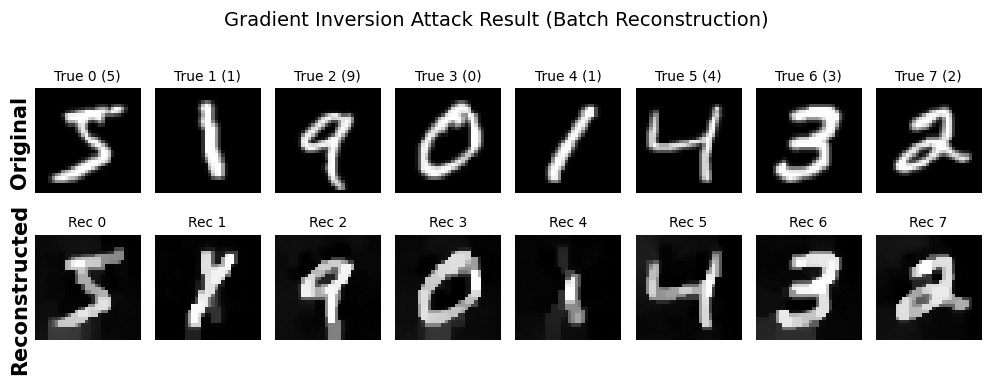

In [ ]:
#attach on client 0's gradient

#tv = 1e-05, iter = 4800

# Execute the attack after the FL simulation finishes
if target_client_gradient is not None:
    print("\n\n#####################################################")
    print("Executing standalone Gradient Inversion Attack...")
    print("#####################################################")
    # true_data_batch and true_label_batch are the batch data/labels that generated the target_client_gradient
    run_gradient_inversion_attack(
        target_model=target_model_for_attack,
        target_gradient=target_client_gradient,
        true_data_batch=target_true_data_batch,
        true_label_batch=target_true_label_batch
    )
else:
    print("\nAttack cannot be run: Target gradient was not successfully captured.")



#####################################################
Executing Aggregated Gradient Inversion Attack (Client 0 + 1)...
#####################################################

--- Starting Gradient Inversion Attack (Batch Size: 16) ---
Attack Config: Iterations=8000, LR=0.01, Cost=sim, TV=1e-06
Iteration: 500/8000. Rec. loss: 0.006190.
Iteration: 1000/8000. Rec. loss: 0.003897.
Iteration: 1500/8000. Rec. loss: 0.003636.
Iteration: 2000/8000. Rec. loss: 0.003559.
Iteration: 2500/8000. Rec. loss: 0.003529.
Iteration: 3000/8000. Rec. loss: 0.003514.
Iteration: 3500/8000. Rec. loss: 0.003508.
Iteration: 4000/8000. Rec. loss: 0.003505.
Iteration: 4500/8000. Rec. loss: 0.003503.
Iteration: 5000/8000. Rec. loss: 0.003503.
Iteration: 5500/8000. Rec. loss: 0.003504.
Iteration: 6000/8000. Rec. loss: 0.003504.
Iteration: 6500/8000. Rec. loss: 0.003504.
Iteration: 7000/8000. Rec. loss: 0.003505.
Iteration: 7500/8000. Rec. loss: 0.003506.
Iteration: 8000/8000. Rec. loss: 0.003505.
Total time: 797.8

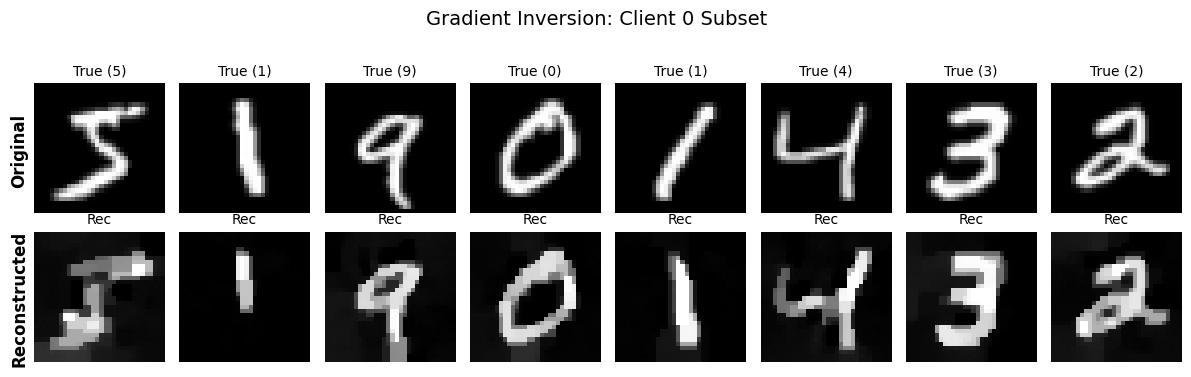

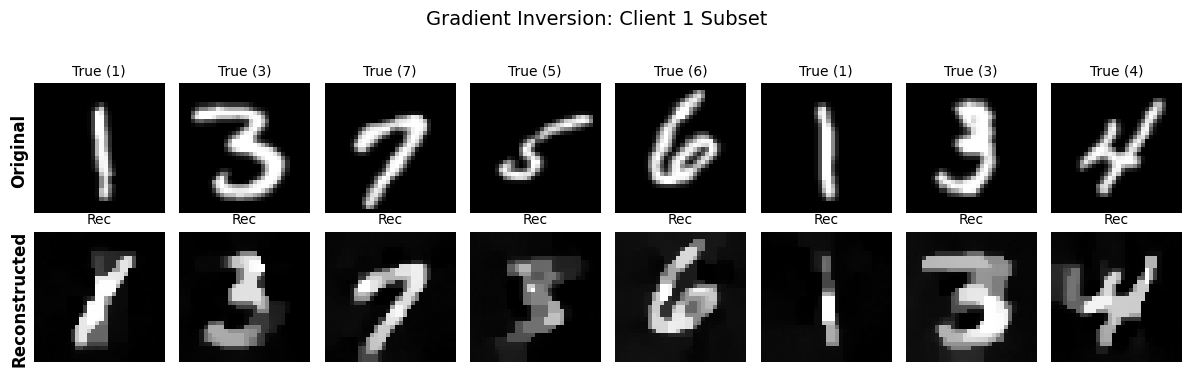

In [ ]:
#attack on aggregated gradient of client

# tv =1e-6, iter = 8k


# ... (Existing execution of Client 0 attack) ...

# --- NEW: Execute Aggregated Gradient Inversion Attack (Client 0 + Client 1) ---
if target_client_gradient is not None and target_client1_gradient is not None:
    print("\n\n#####################################################")
    print("Executing Aggregated Gradient Inversion Attack (Client 0 + 1)...")
    print("#####################################################")

    # 1. Compute the Aggregated Gradient (Weighted Average)
    # This simulates the FedAvg update: Agg_Grad = (n0*g0 + n1*g1) / (n0 + n1)
    n0 = len(target_true_data_batch)
    n1 = len(target_client1_data)
    total_samples = n0 + n1

    aggregated_gradient = []
    for g0, g1 in zip(target_client_gradient, target_client1_gradient):
        # Calculate weighted average for each tensor in the gradient list
        agg_tensor = (g0 * n0 + g1 * n1) / total_samples
        aggregated_gradient.append(agg_tensor)

    # 2. Combine the True Data and Labels for Verification
    # The "Ground Truth" for the aggregated attack is the union of both batches
    agg_true_data = np.concatenate([target_true_data_batch, target_client1_data], axis=0)
    agg_true_labels = np.concatenate([target_true_label_batch, target_client1_labels], axis=0)

    #print(f"Aggregated Batch Size: {len(agg_true_data)} (Client 0: {n0}, Client 1: {n1})")

    # 3. Run the Attack on the Aggregated Gradient
    # Note: We use the same 'target_model_for_attack' because both clients
    # started from the same global model state at Epoch 0.
    run_gradient_inversion_attack(
        target_model=target_model_for_attack,
        target_gradient=aggregated_gradient,
        true_data_batch=agg_true_data,
        true_label_batch=agg_true_labels
    )

else:
    print("\nAggregated attack cannot be run: One or both gradients were not captured.")

Starting FL (Client 0 has 8 images, Batch Size=8)...

Epoch 1
Global Acc: 0.7355

EXECUTING ATTACK ON CLIENT 0 EPOCH UPDATE (FedSGD Scenario)
Adjusting target: Flipping sign of Epoch Delta to match Gradient direction.

--- Starting Reconstruction ---
DEBUG: Target Gradient/Update Norm: 0.025009
Iter: 500, Loss: 0.149086
Iter: 1000, Loss: 0.149159
Iter: 1500, Loss: 0.129865
Iter: 2000, Loss: 0.129974
Iter: 2500, Loss: 0.119997
Iter: 3000, Loss: 0.120155
Iter: 3500, Loss: 0.114950
Iter: 4000, Loss: 0.115019
Time: 386.75s


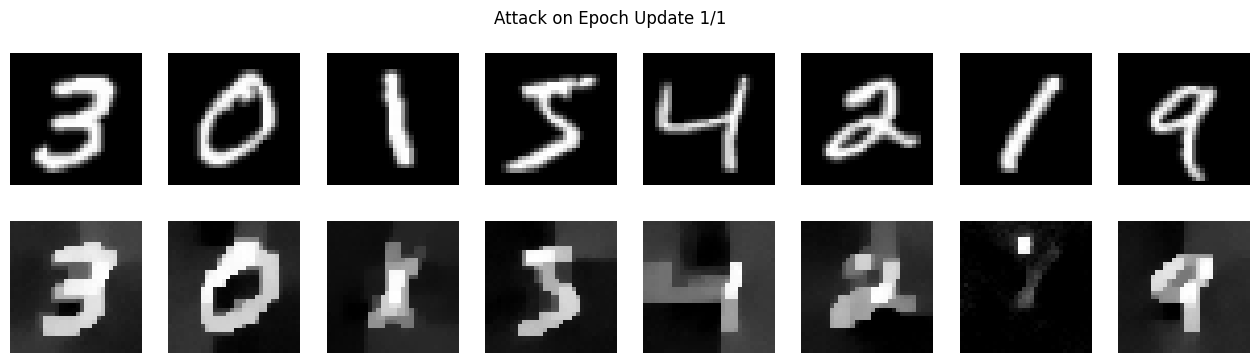

In [ ]:
#Attempt 6 extended
#Somewhat stable version (works with delta instead of gradients)

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, AveragePooling2D, Flatten, Dense
import numpy as np
import time
import matplotlib.pyplot as plt

# ==============================================================================
# 1. SCENARIO CONFIGURATION
# ==============================================================================
CLIENT_DATA_SIZE = 8
BATCH_SIZE = 8

# Configure how long to train and which epoch to attack
TOTAL_EPOCHS = 1
ATTACK_EPOCH_INDEX = 0

ATTACK_CONFIG = {
    'target_type': 'EPOCH_UPDATE',
    'client_id': 0,
    'reconstruction_batch_size': CLIENT_DATA_SIZE
}

DP_CONFIG = {
    'enabled': False,
    'noise_multiplier': 0.001,
    'history_size': 20,
    'smoothing': 0.8,
}

# ==============================================================================
# 2. GRADIENT RECONSTRUCTOR
# ==============================================================================

def total_variation_loss(img):
    return tf.reduce_sum(tf.image.total_variation(img))


def reconstruction_costs_tf_1(trial_gradients, input_gradient, cost_fn='sim'):
    if cost_fn == 'l2':
        total_costs = tf.constant(0.0)
        for trial_grad, input_grad in zip(trial_gradients, input_gradient):
            cost = tf.reduce_sum(tf.square(trial_grad - input_grad))
            total_costs += cost
        return total_costs

    elif cost_fn == 'sim':
        total_cost = tf.constant(0.0)

        for t_g, i_g in zip(trial_gradients, input_gradient):
            t_flat = tf.reshape(t_g, [-1])
            i_flat = tf.reshape(i_g, [-1])

            dot = tf.reduce_sum(t_flat * i_flat)
            norm_t = tf.sqrt(tf.reduce_sum(tf.square(t_flat)))
            norm_i = tf.sqrt(tf.reduce_sum(tf.square(i_flat)))

            sim = dot / (norm_t * norm_i + 1e-8)
            total_cost += (1.0 - sim)

        return total_cost
    else:
        raise ValueError(f"Unknown cost function: {cost_fn}")



def reconstruction_costs_tf(trial_gradients, input_gradient, cost_fn='sim', l2_weight=1e-4):
    """
    Calculates the distance between generated gradients and the target.
    Now supports 'mixed' mode for better reconstruction stability.
    """

    # 1. L2 Cost Calculation (Euclidean Distance)
    # Useful for matching exact pixel intensity
    if cost_fn == 'l2' or cost_fn == 'mixed':
        total_l2_cost = tf.constant(0.0)
        for trial_grad, input_grad in zip(trial_gradients, input_gradient):
            # [cite_start]Sum of squared differences [cite: 3]
            total_l2_cost += tf.reduce_sum(tf.square(trial_grad - input_grad))

        if cost_fn == 'l2':
            return total_l2_cost

    # 2. Cosine Similarity Cost Calculation
    # Useful for matching the shape/structure of the image regardless of scale
    if cost_fn == 'sim' or cost_fn == 'mixed':
        # [cite_start]Flatten gradients into single vectors [cite: 4]
        trial_flat = tf.concat([tf.reshape(g, [-1]) for g in trial_gradients], axis=0)
        input_flat = tf.concat([tf.reshape(g, [-1]) for g in input_gradient], axis=0)

        # [cite_start]Dot product and norms [cite: 4]
        dot_product = tf.reduce_sum(trial_flat * input_flat)
        norm_trial = tf.sqrt(tf.reduce_sum(tf.square(trial_flat)))
        norm_input = tf.sqrt(tf.reduce_sum(tf.square(input_flat)))

        # [cite_start]Cosine Similarity with epsilon for stability [cite: 5]
        cosine_similarity = dot_product / (norm_trial * norm_input + 1e-8)
        total_sim_cost = 1.0 - cosine_similarity

        if cost_fn == 'sim':
            return total_sim_cost

    # 3. Mixed Cost Calculation
    if cost_fn == 'mixed':
        # Combined cost: Primary focus on structure (sim), secondary on intensity (l2)
        return total_sim_cost + (l2_weight * total_l2_cost)

    raise ValueError(f"Unknown cost function: {cost_fn}")



class TensorFlowGradientReconstructor:
    def __init__(self, target_model, num_images, config=None):
        self.target_model = target_model
        self.num_images = num_images
        self.config = {
            'lr': 0.1,
            'optim': 'Adam',
            'max_iterations': 4000,
            'total_variation': 1e-4,
            'cost_fn': 'mixed',
            'l2_weight': 1e-3,
            'init': 'randn',
            'boxed': True,
        }
        if config: self.config.update(config)
        self.client_loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(reduction=tf.keras.losses.Reduction.SUM)

    def _init_images(self, img_shape):
        shape_with_batch = (self.num_images, *img_shape)
        if self.config['init'] == 'randn':
            x = tf.random.normal(shape_with_batch, mean=0.0, stddev=1.0, dtype=tf.float32)
        elif self.config['init'] == 'zeros':
            x = tf.zeros(shape_with_batch, dtype=tf.float32)
        else:
            x = (tf.random.uniform(shape_with_batch, dtype=tf.float32) - 0.5) * 2
        return tf.Variable(x, trainable=True)

    def reconstruct(self, target_update, client_data_shape, dummy_labels):
        print(f"\n--- Starting Reconstruction ---")

        # DEBUG: Check gradient magnitude
        grad_norm = tf.linalg.global_norm(target_update)
        print(f"DEBUG: Target Gradient/Update Norm: {grad_norm.numpy():.6f}")
        if grad_norm.numpy() < 1e-3:
            print("WARNING: Gradient norm is very small! Reconstruction likely to fail (Vanishing Gradient).")

        start_time = time.time()

        x = self._init_images(img_shape=client_data_shape)

        lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
            initial_learning_rate=self.config['lr'],
            decay_steps=self.config['max_iterations'] // 4,
            decay_rate=0.5,
            staircase=True
        )
        optimizer = tf.optimizers.Adam(learning_rate=lr_schedule)

        for iteration in range(self.config['max_iterations']):
            with tf.GradientTape() as tape_outer:
                with tf.GradientTape() as tape_inner:
                    logits = self.target_model(x, training=False)
                    client_loss = self.client_loss_fn(dummy_labels, logits)

                generated_gradients = tape_inner.gradient(client_loss, self.target_model.trainable_variables)

                rec_loss = reconstruction_costs_tf(generated_gradients, target_update, cost_fn=self.config['cost_fn'])

                if self.config['total_variation'] > 0:
                    rec_loss += self.config['total_variation'] * total_variation_loss(x)

            image_grad = tape_outer.gradient(rec_loss, x)
            optimizer.apply_gradients(zip([image_grad], [x]))

            if self.config['boxed']: x.assign(tf.clip_by_value(x, 0.0, 1.0))

            if (iteration + 1) % 500 == 0:
                print(f'Iter: {iteration + 1}, Loss: {rec_loss.numpy():.6f}')

        print(f'Time: {time.time()-start_time:.2f}s')
        return x.numpy()


# ==============================================================================
# 3. FL ENVIRONMENT
# ==============================================================================

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

def prep(x):
    x = np.expand_dims(x, axis=-1)
    x = tf.image.resize(x, [32, 32]).numpy()
    x = np.repeat(x, 3, axis=-1)
    return x

x_train = prep(x_train); x_test = prep(x_test)

# --- CUSTOM DATA PARTITIONING ---
victim_data_x = x_train[:CLIENT_DATA_SIZE]
victim_data_y = y_train[:CLIENT_DATA_SIZE]
other_data_x = x_train[CLIENT_DATA_SIZE:2000]
other_data_y = y_train[CLIENT_DATA_SIZE:2000]

client_data = [(victim_data_x, victim_data_y), (other_data_x, other_data_y)]
num_clients = 2
num_classes = 10

def build_model(input_shape=(32, 32, 3), num_classes=10):
    with tf.device('/cpu:0'):
        inputs = Input(shape=input_shape)
        x = Conv2D(6, 5, activation='tanh', padding='valid')(inputs)
        x = AveragePooling2D(pool_size = (2,2))(x)
        x = Conv2D(16, 5, activation='tanh', padding='valid')(x)
        x = AveragePooling2D(pool_size = (2,2))(x)
        x = Flatten()(x)
        x = Dense(120, activation='tanh')(x)
        x = Dense(84, activation='tanh')(x)
        outputs = Dense(num_classes, activation='softmax')(x)
    return Model(inputs, outputs)

def evaluate_global_model(model):
    logits = model(x_test, training=False)
    acc = tf.reduce_mean(tf.cast(tf.equal(tf.argmax(logits, 1), tf.cast(y_test, tf.int64)), tf.float32))
    print(f"Global Acc: {acc.numpy():.4f}")

global_model_weights_history = []
client_updates_history = []
client_ref_data_history = []

class AdaptiveClipper:
    def __init__(self): self.history = []
    def get_threshold(self, norm):
        self.history.append(norm)
        if(len(self.history)>20): self.history.pop(0)
        return np.median(self.history) if len(self.history) > 1 else max(norm, 0.1)
client_clippers = [AdaptiveClipper() for _ in range(10)]


# --- FL LOOP ---
global_model = build_model()
global_model.build((None, 32, 32, 3))
models = [build_model() for _ in range(num_clients)]
for m in models: m.set_weights(global_model.get_weights())
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

print(f"Starting FL (Client 0 has {CLIENT_DATA_SIZE} images, Batch Size={BATCH_SIZE})...")

for epoch in range(TOTAL_EPOCHS):
    print(f"\nEpoch {epoch+1}")
    current_global_weights = [tf.identity(w) for w in global_model.get_weights()]
    global_model_weights_history.append(current_global_weights)

    epoch_updates = []
    epoch_ref = {}

    for cid, (xc, yc) in enumerate(client_data):
        models[cid].set_weights(current_global_weights)
        #optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
        optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)


        train_ds = tf.data.Dataset.from_tensor_slices((xc, yc)).shuffle(1000).batch(BATCH_SIZE)
        w_start = models[cid].get_weights()

        for xb, yb in train_ds.take(1): epoch_ref[cid] = (xb.numpy(), yb.numpy())

        for step, (xb, yb) in enumerate(train_ds):
            with tf.GradientTape() as tape:
                loss = loss_fn(yb, models[cid](xb, training=True))
            grads = tape.gradient(loss, models[cid].trainable_variables)
            optimizer.apply_gradients(zip(grads, models[cid].trainable_variables))

        w_end = models[cid].get_weights()
        delta = [tf.identity(n-o) for n,o in zip(w_end, w_start)]

        if DP_CONFIG['enabled']:
            norm = tf.linalg.global_norm(delta)
            C = client_clippers[cid].get_threshold(norm.numpy())
            delta, _ = tf.clip_by_global_norm(delta, C)
            delta = [d + tf.random.normal(d.shape, stddev=DP_CONFIG['noise_multiplier']*C) for d in delta]
            models[cid].set_weights([s+d for s,d in zip(w_start, delta)])

        epoch_updates.append(delta)

    client_updates_history.append(epoch_updates)
    client_ref_data_history.append(epoch_ref)

    agg = [tf.reduce_mean(x, 0) for x in zip(*epoch_updates)]
    global_model.set_weights([o+u for o,u in zip(current_global_weights, agg)])
    evaluate_global_model(global_model)


# ==============================================================================
# 4. ATTACK EXECUTION
# ==============================================================================
print(f"\nEXECUTING ATTACK ON CLIENT 0 EPOCH UPDATE (FedSGD Scenario)")

target_epoch = ATTACK_EPOCH_INDEX
cid = ATTACK_CONFIG['client_id']
base_weights = global_model_weights_history[target_epoch]

# Get the target update (Delta)
target = client_updates_history[target_epoch][cid]

# --- FIX FOR EPOCH UPDATE ATTACK ---
# Delta = -Eta * Gradient.
# Since we use Cosine Similarity, we just need to fix the Direction.
# Flip the sign of the update to match the gradient direction.
if ATTACK_CONFIG['target_type'] == 'EPOCH_UPDATE':
    print("Adjusting target: Flipping sign of Epoch Delta to match Gradient direction.")
    target = [t * -1.0 for t in target]

attack_model = build_model()
attack_model.set_weights(base_weights)

reconstructor = TensorFlowGradientReconstructor(attack_model, CLIENT_DATA_SIZE)

ref_imgs, ref_labels = client_ref_data_history[target_epoch][cid]
dummy_labels = tf.constant(ref_labels, dtype=tf.int32)

recovered = reconstructor.reconstruct(target, (32, 32, 3), dummy_labels)

fig, axes = plt.subplots(2, CLIENT_DATA_SIZE, figsize=(CLIENT_DATA_SIZE * 2, 4))
for i in range(CLIENT_DATA_SIZE):
    axes[0, i].imshow(ref_imgs[i][:,:,0], cmap='gray'); axes[0,i].axis('off')
    axes[1, i].imshow(recovered[i][:,:,0], cmap='gray'); axes[1,i].axis('off')
plt.suptitle(f"Attack on Epoch Update {ATTACK_EPOCH_INDEX+1}/{TOTAL_EPOCHS}")
plt.show()